## Analise Exploratória do DataSet DataSUS - SRAG
By Iasmin Maeques

Dados Link da fonte de dados: https://opendatasus.saude.gov.br/dataset/srag-2021-a-2024

Link do repositorio do github https://github.com/iasminimp/srag_tcc

In [4]:
# Instalação de bibliotecas
!pip install pandas scikit-learn seaborn matplotlib --quiet

In [5]:
# Importações principais
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc
from xgboost import XGBClassifier
import numpy as np
sns.set(style='whitegrid')

In [66]:
# Carregar os dados
df = pd.read_csv("/content/drive/MyDrive/TCC I/Analise de Dados/INFLUD24-03-02-2025.csv", sep=";", encoding="latin1", low_memory=False)
df

,DT_NOTIFIC,SEM_NOT,DT_SIN_PRI,SEM_PRI,SG_UF_NOT,ID_REGIONA,CO_REGIONA,ID_MUNICIP,CO_MUN_NOT,ID_UNIDADE,...,VG_REINF,REINF,FAB_ADIC,LOT_RE_BI,FAB_RE_BI,DOSE_ADIC,DOS_RE_BI,LOTE_ADIC,TABAG,CASO_SRAG
0,04/01/2024,1,04/01/2024,1,CE,1 CRES FORTALEZA,1519.0,FORTALEZA,230440,SOPAI HOSPITAL INFANTIL,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,15/01/2024,3,31/12/2023,1,BA,NUCLEO REGIONAL DE SAUDE LESTE,1380.0,SALVADOR,292740,CARDIO PULMONAR DA BAHIA,...,NaN,2,NaN,GF9673,103 - COVID-19 PFIZER - COMIRNATY BIVALENTE,NaN,03/03/2023,NaN,NaN,1.0
2,15/01/2024,3,10/01/2024,2,PB,I NRS JOAO PESSOA,1377.0,JOAO PESSOA,250750,HOSPITAL DE EMERGENCIA E TRAUMA SENADOR HUMBER...,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,11/01/2024,2,04/01/2024,1,GO,SUDOESTE II,1800.0,JATAI,521190,HOSPITAL PADRE TIAGO NA PROVIDENCIA DE DEUS,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,16/01/2024,3,14/01/2024,3,BA,NUCLEO REGIONAL DE SAUDE LESTE,1380.0,SALVADOR,292740,PA MARIA DA CONCEICAO SANTIAGO IMBASSAY,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266425,27/11/2024,48,23/11/2024,47,MG,BELO HORIZONTE,1449.0,BELO HORIZONTE,310620,HOSPITAL INFANTIL JOAO PAULO II,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
266426,06/12/2024,49,04/12/2024,49,MG,GOVERNADOR VALADARES,1471.0,GOVERNADOR VALADARES,312770,HOSPITAL MUNICIPAL,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
266427,16/12/2024,51,13/12/2024,50,SP,GVE XXXI SOROCABA,1353.0,ITU,352390,VIGILANCIA EPIDEMIOLOGICA,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
266428,05/12/2024,49,04/12/2024,49,DF,NaN,NaN,BRASILIA,530010,HOSPITAL AGUAS CLARAS,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [7]:
# definindo colunas obrigatorias e algumas essenciais
colunas_obrigatorias = [
    "DT_NOTIFIC", "DT_SIN_PRI", "SG_UF_NOT","ID_MUNICIP", "CO_MUN_NOT", "ID_UNIDADE", "CO_UNI_NOT","TEM_CPF", "NU_CPF", "ESTRANG", "NU_CNS","NM_PACIENT", "CS_SEXO", "NU_IDADE_N", "TP_IDADE",
    "CS_GESTANT", "CS_RACA", "POV_CT", "TP_POV_CT","SG_UF", "ID_MN_RESI", "CO_MUN_RES","ID_PAIS", "CO_PAIS", "VACINA_COV",
    "DT_INTERNA", "CLASSI_FIN", "CLASSI_OUT", "DT_ENCERRA","EVOLUCAO", "DT_NASC", "FATOR_RISC", "DT_RES", "DT_EVOLUCA", "NU_DO"
]

In [8]:
# Verifica quais colunas da lista existem no DataFrame
colunas_presentes = [col for col in colunas_obrigatorias if col in df.columns]

# Filtra apenas essas colunas
df_obrigatorio = df[colunas_presentes]

# Visualiza o novo DataFrame (5 pimeiros)
df_obrigatorio.head()

,DT_NOTIFIC,DT_SIN_PRI,SG_UF_NOT,ID_MUNICIP,CO_MUN_NOT,ID_UNIDADE,CO_UNI_NOT,ESTRANG,CS_SEXO,NU_IDADE_N,...,VACINA_COV,DT_INTERNA,CLASSI_FIN,CLASSI_OUT,DT_ENCERRA,EVOLUCAO,DT_NASC,FATOR_RISC,DT_RES,DT_EVOLUCA
0,04/01/2024,04/01/2024,CE,FORTALEZA,230440,SOPAI HOSPITAL INFANTIL,2526638,2.0,F,4,...,2.0,NaN,4.0,NaN,12/01/2024,1.0,15/08/2019,1,NaN,12/01/2024
1,15/01/2024,31/12/2023,BA,SALVADOR,292740,CARDIO PULMONAR DA BAHIA,3814378,2.0,M,79,...,1.0,12/01/2024,5.0,NaN,01/02/2024,1.0,26/07/1944,1,NaN,18/01/2024
2,15/01/2024,10/01/2024,PB,JOAO PESSOA,250750,HOSPITAL DE EMERGENCIA E TRAUMA SENADOR HUMBER...,2593262,2.0,M,59,...,2.0,10/01/2024,5.0,NaN,24/01/2024,3.0,24/07/1964,1,NaN,24/01/2024
3,11/01/2024,04/01/2024,GO,JATAI,521190,HOSPITAL PADRE TIAGO NA PROVIDENCIA DE DEUS,7532024,2.0,M,72,...,1.0,NaN,4.0,NaN,16/01/2024,2.0,21/10/1951,1,NaN,14/01/2024
4,16/01/2024,14/01/2024,BA,SALVADOR,292740,PA MARIA DA CONCEICAO SANTIAGO IMBASSAY,7033753,2.0,F,84,...,2.0,16/01/2024,4.0,NaN,25/01/2024,9.0,19/09/1939,1,NaN,NaN


In [9]:
#campos que estao faltando no df
colunas_faltando = [col for col in colunas_obrigatorias if col not in df.columns]
print("Colunas ausentes no DataFrame:", colunas_faltando)

Colunas ausentes no DataFrame: ['TEM_CPF', 'NU_CPF', 'NU_CNS', 'NM_PACIENT', 'POV_CT', 'TP_POV_CT', 'NU_DO']


In [10]:
df_obrigatorio.to_csv("df_srag_obito_limpo.csv", index=False)
df_obrigatorio

,DT_NOTIFIC,DT_SIN_PRI,SG_UF_NOT,ID_MUNICIP,CO_MUN_NOT,ID_UNIDADE,CO_UNI_NOT,ESTRANG,CS_SEXO,NU_IDADE_N,...,VACINA_COV,DT_INTERNA,CLASSI_FIN,CLASSI_OUT,DT_ENCERRA,EVOLUCAO,DT_NASC,FATOR_RISC,DT_RES,DT_EVOLUCA
0,04/01/2024,04/01/2024,CE,FORTALEZA,230440,SOPAI HOSPITAL INFANTIL,2526638,2.0,F,4,...,2.0,NaN,4.0,NaN,12/01/2024,1.0,15/08/2019,1,NaN,12/01/2024
1,15/01/2024,31/12/2023,BA,SALVADOR,292740,CARDIO PULMONAR DA BAHIA,3814378,2.0,M,79,...,1.0,12/01/2024,5.0,NaN,01/02/2024,1.0,26/07/1944,1,NaN,18/01/2024
2,15/01/2024,10/01/2024,PB,JOAO PESSOA,250750,HOSPITAL DE EMERGENCIA E TRAUMA SENADOR HUMBER...,2593262,2.0,M,59,...,2.0,10/01/2024,5.0,NaN,24/01/2024,3.0,24/07/1964,1,NaN,24/01/2024
3,11/01/2024,04/01/2024,GO,JATAI,521190,HOSPITAL PADRE TIAGO NA PROVIDENCIA DE DEUS,7532024,2.0,M,72,...,1.0,NaN,4.0,NaN,16/01/2024,2.0,21/10/1951,1,NaN,14/01/2024
4,16/01/2024,14/01/2024,BA,SALVADOR,292740,PA MARIA DA CONCEICAO SANTIAGO IMBASSAY,7033753,2.0,F,84,...,2.0,16/01/2024,4.0,NaN,25/01/2024,9.0,19/09/1939,1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266425,27/11/2024,23/11/2024,MG,BELO HORIZONTE,310620,HOSPITAL INFANTIL JOAO PAULO II,26948,2.0,F,11,...,1.0,26/11/2024,4.0,NaN,20/12/2024,1.0,07/09/2013,1,NaN,05/12/2024
266426,06/12/2024,04/12/2024,MG,GOVERNADOR VALADARES,312770,HOSPITAL MUNICIPAL,2222043,2.0,M,3,...,2.0,06/12/2024,2.0,NaN,27/01/2025,1.0,09/09/2024,2,NaN,21/12/2024
266427,16/12/2024,13/12/2024,SP,ITU,352390,VIGILANCIA EPIDEMIOLOGICA,2802511,2.0,M,3,...,2.0,NaN,NaN,NaN,NaN,NaN,15/08/2021,1,NaN,NaN
266428,05/12/2024,04/12/2024,DF,BRASILIA,530010,HOSPITAL AGUAS CLARAS,49867,2.0,F,2,...,2.0,05/12/2024,2.0,NaN,05/12/2024,1.0,22/08/2022,2,NaN,19/12/2024


## Grafico baseado nos registros de sexo da pessoa
Coluna CS_SEXO, onde:

'M': 'Masculino',

'F': 'Feminino',

'I': 'Ignorado'


<ipython-input-11-a65594459024>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sexo_counts.index, y=sexo_counts.values, palette='pastel')


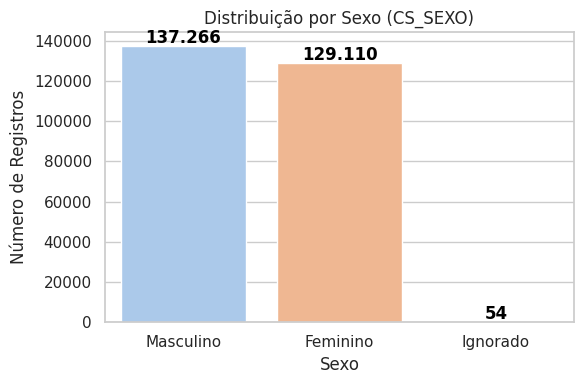

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mapear os valores para nomes legíveis
sexo_map = {
    'M': 'Masculino',
    'F': 'Feminino',
    'I': 'Ignorado'
}
df['CS_SEXO_LABEL'] = df['CS_SEXO'].map(sexo_map)

# Contar valores
sexo_counts = df['CS_SEXO_LABEL'].value_counts()

# Plotar gráfico
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=sexo_counts.index, y=sexo_counts.values, palette='pastel')

# Adicionar rótulos numéricos em cima de cada barra
for i, v in enumerate(sexo_counts.values):
    ax.text(i, v + max(sexo_counts.values) * 0.01, f"{v:,.0f}".replace(",", "."),
            color='black', ha='center', fontweight='bold')

plt.title('Distribuição por Sexo (CS_SEXO)')
plt.xlabel('Sexo')
plt.ylabel('Número de Registros')
plt.tight_layout()
plt.show()


## Gráfico baseado na UF da unidade de Notificação
SG_UF_NOT: unidade Federativa onde está localizada a Unidade que realizou a notificação

<ipython-input-12-9e80068cd669>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=uf_counts.index, y=uf_counts.values, palette='crest')


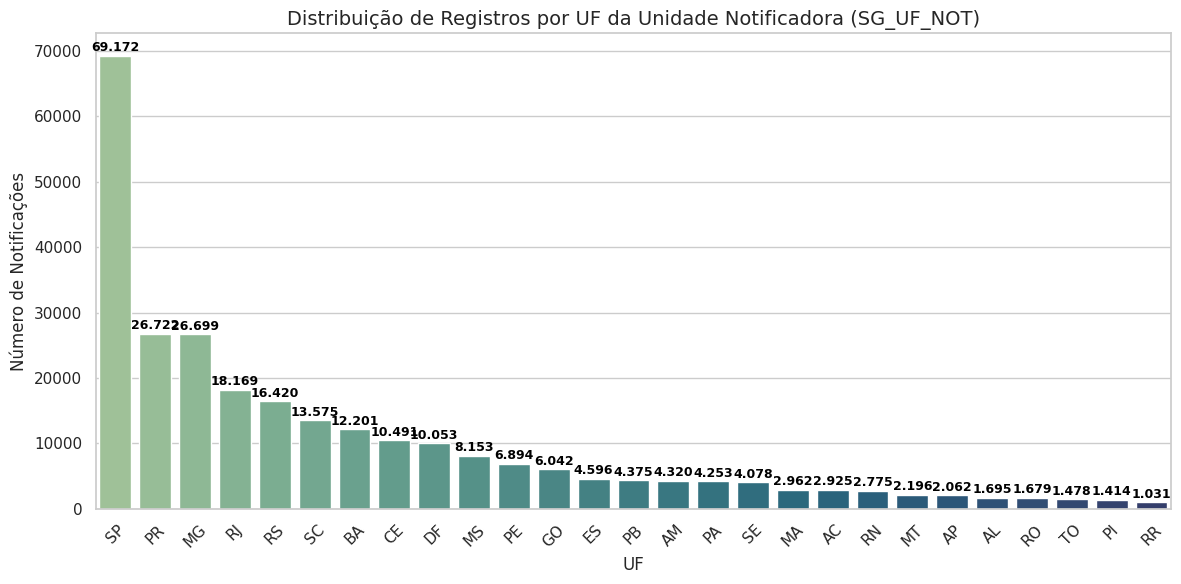

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contagem de notificações por UF
uf_counts = df['SG_UF_NOT'].value_counts().sort_values(ascending=False)

# Plotar o gráfico
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=uf_counts.index, y=uf_counts.values, palette='crest')

# Adicionar rótulos numéricos nas barras
for i, v in enumerate(uf_counts.values):
    ax.text(i, v + max(uf_counts.values) * 0.01, f"{v:,.0f}".replace(",", "."),
            color='black', ha='center', fontweight='bold', fontsize=9)

plt.title('Distribuição de Registros por UF da Unidade Notificadora (SG_UF_NOT)', fontsize=14)
plt.xlabel('UF')
plt.ylabel('Número de Notificações')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Grafico baseado na Idade do Paciente
Distribuição de Idade Informada/Aparente (NU_IDADE_N).
O campo NU_IDADE_N: Idade informada pelo paciente quando não se sabe a data de nascimento.

Na falta desse dado é registrada a idade aparente.
Obs.: limitado por 0 a 120 anos;

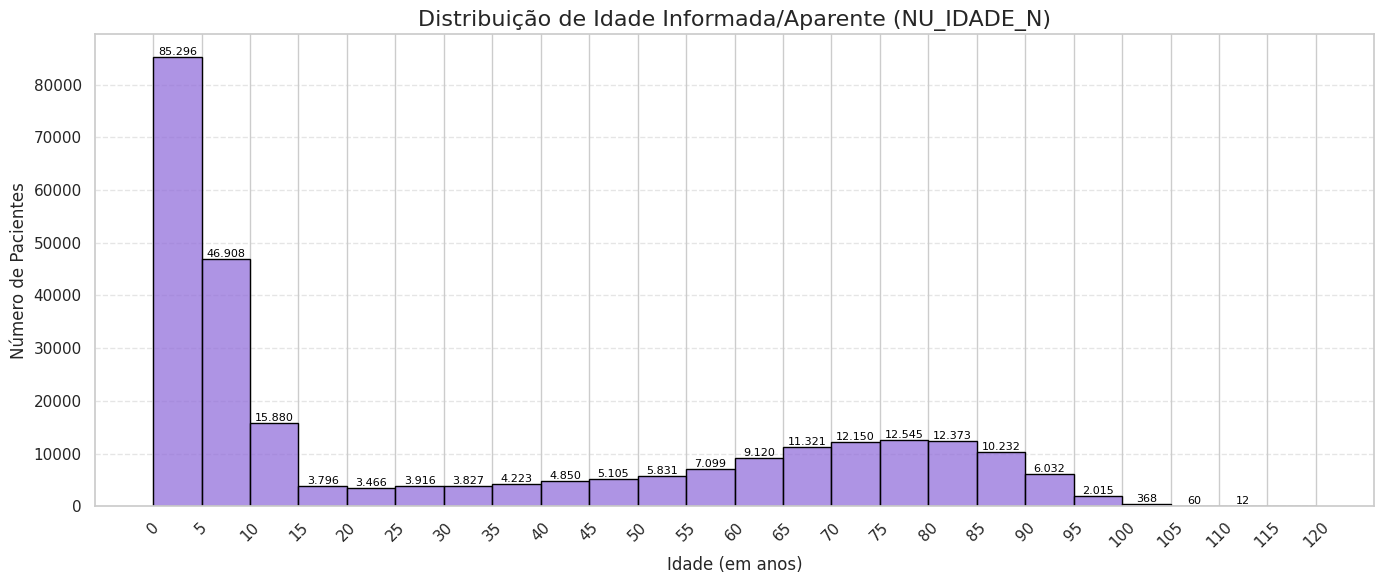

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Filtrar idades válidas
df_idade = df[df['NU_IDADE_N'].notnull()]
df_idade = df_idade[df_idade['NU_IDADE_N'] >= 0]
df_idade = df_idade[df_idade['NU_IDADE_N'] <= 120]  # limitar idade a 0–120 anos

# Bins por faixa de 5 anos
bins = np.arange(0, 125, 5)

# Plot
plt.figure(figsize=(14, 6))
ax = sns.histplot(df_idade['NU_IDADE_N'], bins=bins, color='mediumpurple', edgecolor='black')

# Rótulos nas barras (opcional)
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height()):,}'.replace(',', '.'),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=8, color='black')

# Ajustes visuais
plt.title('Distribuição de Idade Informada/Aparente (NU_IDADE_N)', fontsize=16)
plt.xlabel('Idade (em anos)', fontsize=12)
plt.ylabel('Número de Pacientes', fontsize=12)
plt.xticks(bins, rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


CS_GESTANT: Idade gestacional da paciente.
Sendo que:
1-1º Trimestre
2-2º Trimestre
3-3º Trimestre
4-Idade Gestacional
Ignorada
5-Não
6-Não se aplica
9-Ignorado


<ipython-input-14-5cf89c642c12>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


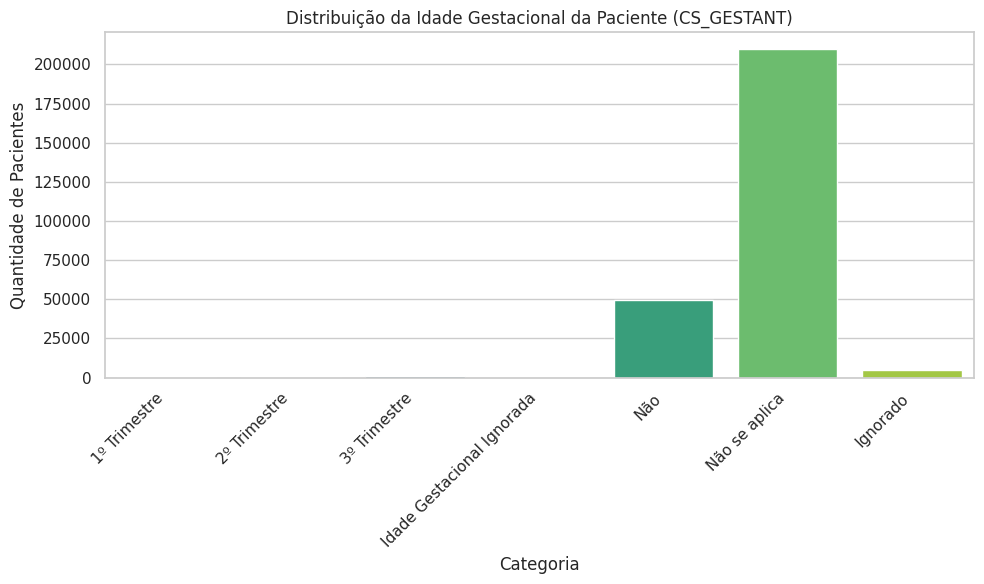

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Exemplo de dados simulados (você deve substituir pelo seu df real)
# df = pd.read_csv('seu_arquivo.csv')

# Mapear os códigos para as descrições
gestational_age_map = {
    1: '1º Trimestre',
    2: '2º Trimestre',
    3: '3º Trimestre',
    4: 'Idade Gestacional Ignorada',
    5: 'Não',
    6: 'Não se aplica',
    9: 'Ignorado'
}

# Substituir valores na coluna para as descrições
df['CS_GESTANT_DESC'] = df['CS_GESTANT'].map(gestational_age_map)

# Contar frequências
counts = df['CS_GESTANT_DESC'].value_counts().reindex(gestational_age_map.values())

# Plotar gráfico de barras
plt.figure(figsize=(10,6))
sns.barplot(x=counts.index, y=counts.values, palette="viridis")

plt.title('Distribuição da Idade Gestacional da Paciente (CS_GESTANT)')
plt.xlabel('Categoria')
plt.ylabel('Quantidade de Pacientes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

CS_RACA: Cor ou raça declarada pelo paciente:
Branca; Preta; Amarela; Parda (pessoa que se declarou mulata, cabocla, cafuza, mameluca ou mestiça de preto com pessoa de outra cor ou raça); e, Indígena.

Onde:
1-Branca
2-Preta
3-Amarela
4-Parda
5-Indígena
9-Ignorado

<ipython-input-15-03b1de160d0f>:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=counts.index, y=counts.values, palette='Set2')


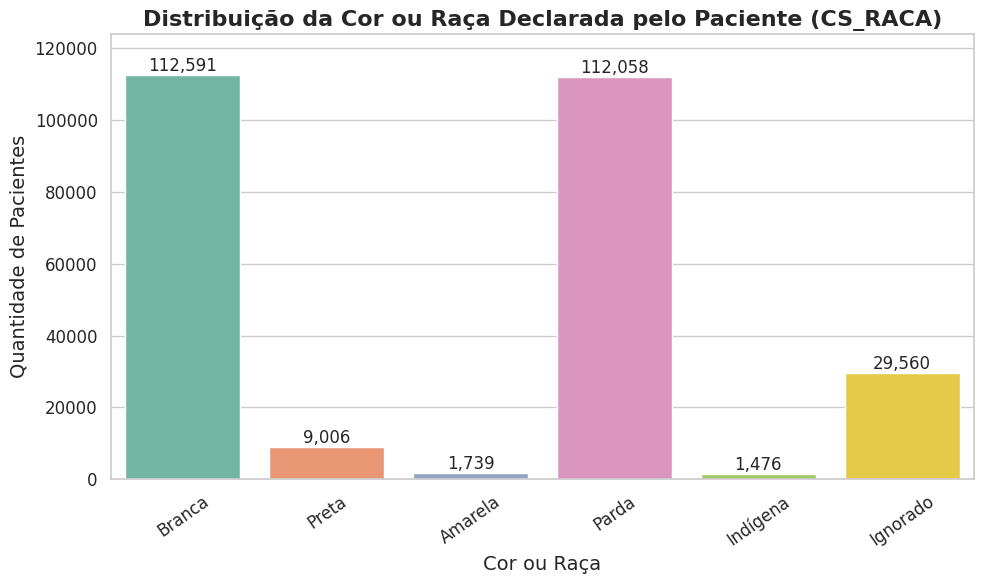

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Mapear os códigos para categorias
raca_map = {
    1: 'Branca',
    2: 'Preta',
    3: 'Amarela',
    4: 'Parda',
    5: 'Indígena',
    9: 'Ignorado'
}

df['CS_RACA_DESC'] = df['CS_RACA'].map(raca_map)

order = ['Branca', 'Preta', 'Amarela', 'Parda', 'Indígena', 'Ignorado']
counts = df['CS_RACA_DESC'].value_counts().reindex(order)

plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

barplot = sns.barplot(x=counts.index, y=counts.values, palette='Set2')

# Adicionar valores acima das barras
for index, value in enumerate(counts.values):
    barplot.text(index, value + max(counts.values)*0.01, f'{value:,}', ha='center', fontsize=12)

plt.title('Distribuição da Cor ou Raça Declarada pelo Paciente (CS_RACA)', fontsize=16, weight='bold')
plt.xlabel('Cor ou Raça', fontsize=14)
plt.ylabel('Quantidade de Pacientes', fontsize=14)
plt.xticks(rotation=35, fontsize=12)
plt.yticks(fontsize=12)

plt.ylim(0, counts.max() * 1.1)  # espaço extra para os valores acima das barras

plt.tight_layout()
plt.show()


## Pais de residencia do paciente
ID_PAIS: País de residência do paciente.
Tabela com código e nome dos Países.

<ipython-input-16-1ccdcd498f5f>:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=top_paises.index, y=top_paises.values, palette='mako')


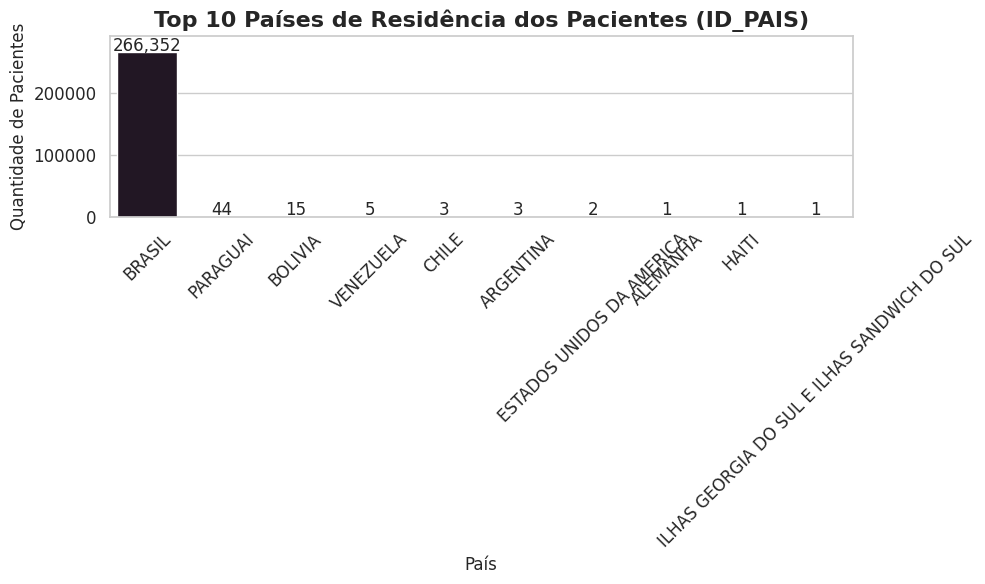

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Suponha que df tenha a coluna ID_PAIS com códigos numéricos dos países

# Se você tiver um dicionário para mapear código para país, por exemplo:
pais_map = {
    1058: 'Brasil',
    1065: 'Argentina',
    1077: 'Chile',
    1081: 'Colômbia',
    # ... adicione mais conforme seu dicionário
}

# Mapear códigos para nomes (se tiver)
if 'ID_PAIS' in df.columns:
    df['PAIS'] = df['ID_PAIS'].map(pais_map)
else:
    print("Coluna ID_PAIS não encontrada no DataFrame.")

# Se não tem o mapeamento, pode usar os códigos mesmo:
df['PAIS'] = df['PAIS'].fillna(df['ID_PAIS'].astype(str))

# Contar os 10 países mais frequentes
top_paises = df['PAIS'].value_counts().head(10)

# Plotar gráfico de barras
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")
barplot = sns.barplot(x=top_paises.index, y=top_paises.values, palette='mako')

# Adicionar valores acima das barras
for index, value in enumerate(top_paises.values):
    barplot.text(index, value + max(top_paises.values)*0.01, f'{value:,}', ha='center', fontsize=12)

plt.title('Top 10 Países de Residência dos Pacientes (ID_PAIS)', fontsize=16, weight='bold')
plt.xlabel('País')
plt.ylabel('Quantidade de Pacientes')
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.ylim(0, top_paises.max() * 1.1)
plt.tight_layout()
plt.show()


VACINA_COV: informar se o paciente recebeu vacina COVID-19, após verificar a documentação / caderneta.

Onde:
1-Sim
2-Não
9-Ignorado

<ipython-input-17-86cc577284b2>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=counts.index, y=counts.values, palette=palette)


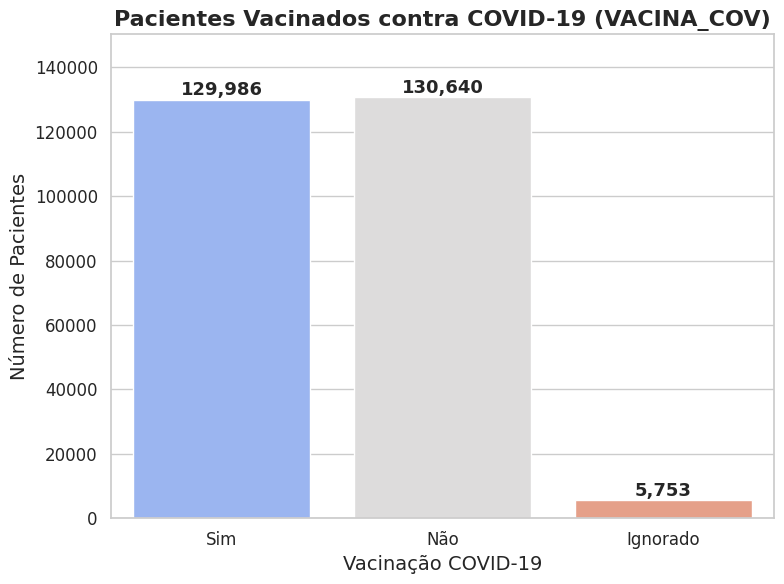

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Mapeamento dos códigos
vacina_map = {
    1: 'Sim',
    2: 'Não',
    9: 'Ignorado'
}

# Mapear os valores
df['VACINA_COV_DESC'] = df['VACINA_COV'].map(vacina_map)

# Contar frequências na ordem correta
order = ['Sim', 'Não', 'Ignorado']
counts = df['VACINA_COV_DESC'].value_counts().reindex(order)

# Configurações de estilo
plt.figure(figsize=(8,6))
sns.set_style("whitegrid")

# Cores suaves
palette = sns.color_palette("coolwarm", len(counts))
barplot = sns.barplot(x=counts.index, y=counts.values, palette=palette)

# Mostrar valores acima das barras
for i, v in enumerate(counts.values):
    barplot.text(i, v + max(counts.values)*0.01, f'{v:,}', ha='center', fontsize=13, weight='bold')

# Título e labels
plt.title('Pacientes Vacinados contra COVID-19 (VACINA_COV)', fontsize=16, weight='bold')
plt.xlabel('Vacinação COVID-19', fontsize=14)
plt.ylabel('Número de Pacientes', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0, counts.max() * 1.15)

plt.tight_layout()
plt.show()


# Classificação Final
CLASSI_FIN: Diagnóstico final do caso.
Se tiver resultados divergentes entre as metodologias laboratoriais, priorizar  
resultado  do  RT-PCR.

* RT-PCR: É um diagnóstico laboratorial, feito por biologia molecular, que permite identificar a presença do material genético (RNA) do vírus Sars-Cov-2 em amostras de secreção respiratória

| Código | Descrição                         |
| ------ | --------------------------------- |
| 1      | SRAG por Influenza                |
| 2      | SRAG por outro vírus respiratório |
| 3      | SRAG por outro agente etiológico  |
| 4      | SRAG não especificado             |
| 5      | SRAG por COVID-19                 |


<ipython-input-18-ecb1e5ac7379>:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=counts.index, y=counts.values, palette=colors)


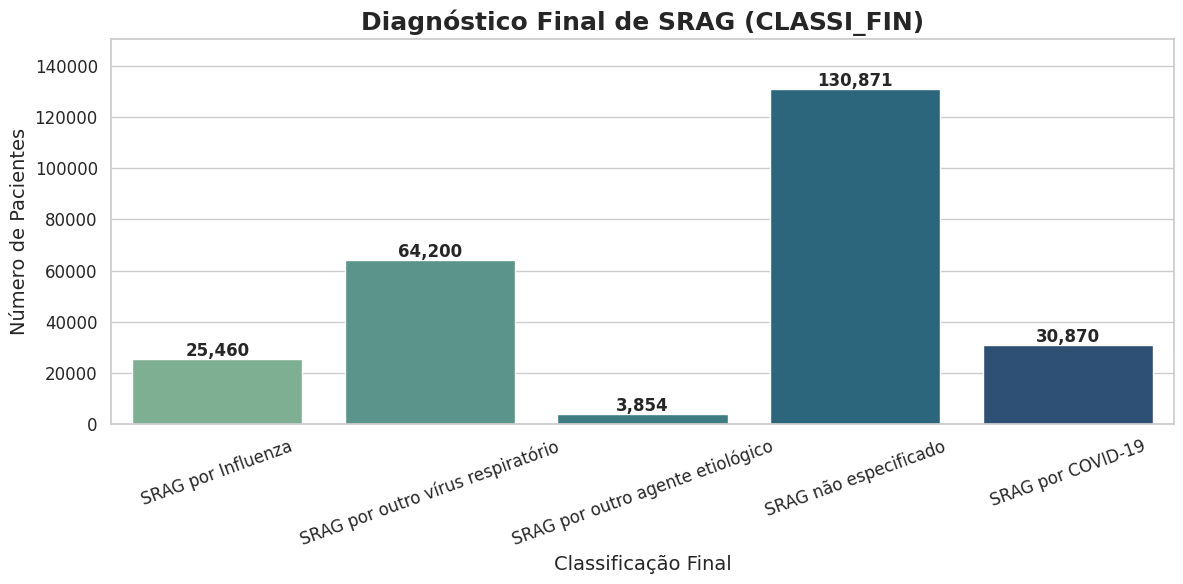

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Mapeamento dos códigos
classi_fin_map = {
    1: 'SRAG por Influenza',
    2: 'SRAG por outro vírus respiratório',
    3: 'SRAG por outro agente etiológico',
    4: 'SRAG não especificado',
    5: 'SRAG por COVID-19'
}

# Mapear os valores
df['CLASSI_FIN_DESC'] = df['CLASSI_FIN'].map(classi_fin_map)

# Contar as frequências e garantir ordem lógica
order = [
    'SRAG por Influenza',
    'SRAG por outro vírus respiratório',
    'SRAG por outro agente etiológico',
    'SRAG não especificado',
    'SRAG por COVID-19'
]
counts = df['CLASSI_FIN_DESC'].value_counts().reindex(order)

# Plot com estilo bonito
plt.figure(figsize=(12,6))
sns.set_style("whitegrid")
colors = sns.color_palette("crest", len(order))

barplot = sns.barplot(x=counts.index, y=counts.values, palette=colors)

# Adicionar valores acima das barras
for i, v in enumerate(counts.values):
    barplot.text(i, v + max(counts.values)*0.01, f'{v:,}', ha='center', fontsize=12, weight='bold')

# Títulos e rótulos
plt.title('Diagnóstico Final de SRAG (CLASSI_FIN)', fontsize=18, weight='bold')
plt.xlabel('Classificação Final', fontsize=14)
plt.ylabel('Número de Pacientes', fontsize=14)
plt.xticks(rotation=20, fontsize=12)
plt.yticks(fontsize=12)

plt.ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()


CLASSI_OUT: Descrição de qual outro agente etiológico foi identificado

<ipython-input-19-a63ff4eb6d58>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=top_classi_out.values, y=top_classi_out.index, palette=colors)


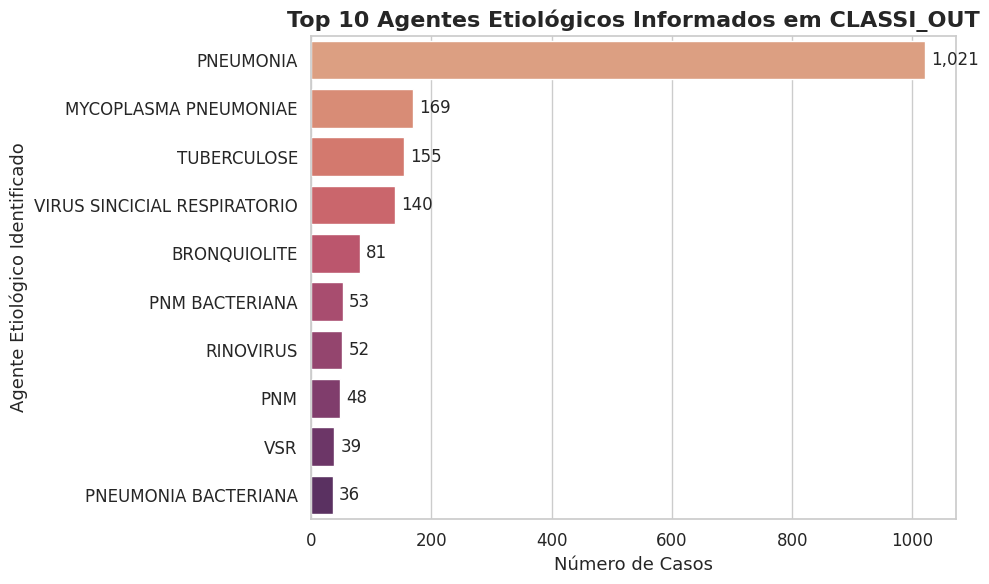

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Remover valores nulos ou em branco
df_outros = df['CLASSI_OUT'].dropna()
df_outros = df_outros[df_outros.str.strip() != '']

# Contar os 10 mais frequentes
top_classi_out = df_outros.value_counts().head(10)

# Plotar gráfico de barras horizontais
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")
colors = sns.color_palette("flare", len(top_classi_out))

barplot = sns.barplot(x=top_classi_out.values, y=top_classi_out.index, palette=colors)

# Adicionar valores ao lado das barras
for i, v in enumerate(top_classi_out.values):
    barplot.text(v + max(top_classi_out.values)*0.01, i, f'{v:,}', va='center', fontsize=12)

plt.title('Top 10 Agentes Etiológicos Informados em CLASSI_OUT', fontsize=16, weight='bold')
plt.xlabel('Número de Casos', fontsize=13)
plt.ylabel('Agente Etiológico Identificado', fontsize=13)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()


## word cloud Agentes Etiológicos Informados em CLASSI_OUT

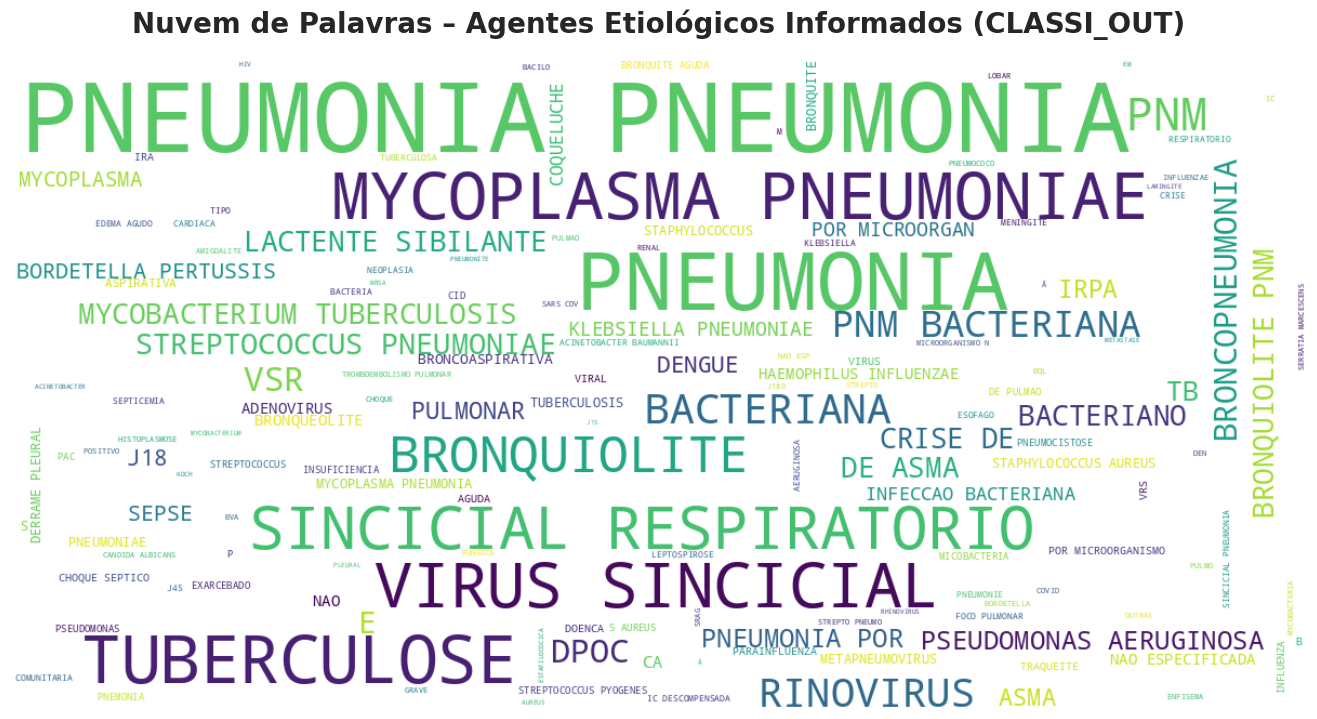

In [20]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Filtrar apenas CLASSI_FIN == 3 e textos válidos
df_outros = df[df['CLASSI_FIN'] == 3]['CLASSI_OUT'].dropna()
df_outros = df_outros[df_outros.str.strip() != '']

# Concatenar todos os agentes em uma string
texto = ' '.join(df_outros.astype(str).tolist())

# Stopwords personalizadas para remover termos irrelevantes (adicione mais se quiser)
stopwords = set(STOPWORDS)
stopwords.update([
    'não', 'informado', 'outro', 'outros', 'agente', 'etiológico',
    'identificado', 'qual', 'causador', 'causada', 'causado'
])

# Criar a word cloud com estilo aprimorado
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    stopwords=stopwords,
    colormap='viridis',  # alternativa: 'plasma', 'magma', 'inferno'
    max_words=150,
    max_font_size=90,
    contour_color='steelblue',
    contour_width=2,
    random_state=42
).generate(texto)

# Exibir
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nuvem de Palavras – Agentes Etiológicos Informados (CLASSI_OUT)', fontsize=20, weight='bold', pad=20)
plt.tight_layout(pad=0)
plt.show()


# Evolução dos Casos

EVOLUCAO: Evolução do caso; Onde:

| Código | Descrição               |
| ------ | ----------------------- |
| 1      | Cura                    |
| 2      | Óbito                   |
| 3      | Óbito por outras causas |
| 9      | Ignorado                |


<ipython-input-21-72234d7c4652>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=counts.index, y=counts.values, palette=colors)


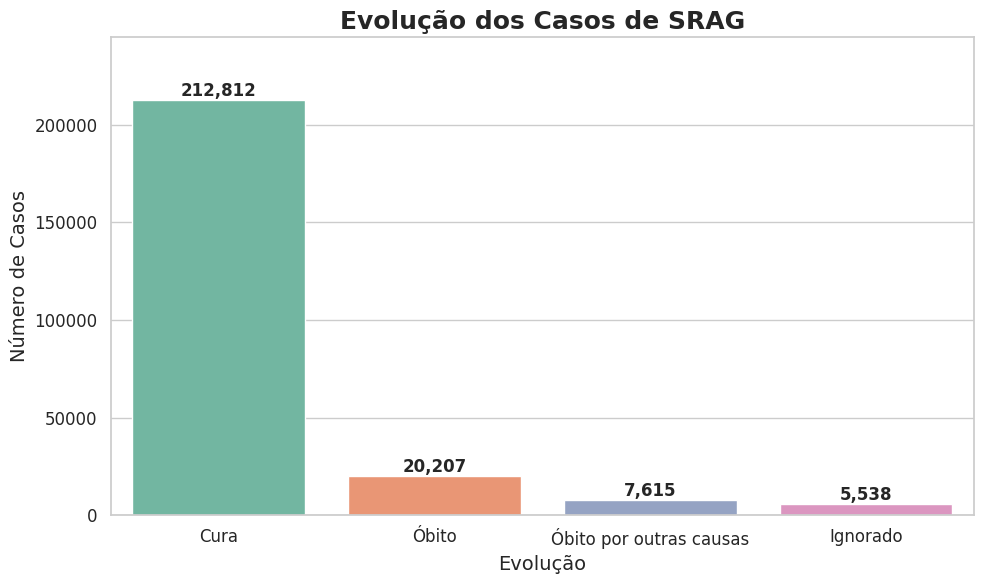

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Mapeamento dos valores
evolucao_map = {
    1: 'Cura',
    2: 'Óbito',
    3: 'Óbito por outras causas',
    9: 'Ignorado'
}

# Mapear os valores
df['EVOLUCAO_DESC'] = df['EVOLUCAO'].map(evolucao_map)

# Contagem com ordenação personalizada
order = ['Cura', 'Óbito', 'Óbito por outras causas', 'Ignorado']
counts = df['EVOLUCAO_DESC'].value_counts().reindex(order)

# Estilo e cores
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")
colors = sns.color_palette("Set2", len(order))

barplot = sns.barplot(x=counts.index, y=counts.values, palette=colors)

# Adiciona os valores acima das barras
for i, v in enumerate(counts.values):
    barplot.text(i, v + max(counts.values)*0.01, f'{v:,}', ha='center', fontsize=12, weight='bold')

# Títulos e rótulos
plt.title('Evolução dos Casos de SRAG', fontsize=18, weight='bold')
plt.xlabel('Evolução', fontsize=14)
plt.ylabel('Número de Casos', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()


# Fator de Risco

FATOR_RISC: Paciente apresenta algum fator de risco.
Onde:

| Código | Descrição |
| ------ | --------- |
| 1      | Sim       |
| 2      | Não       |
| 9      | Ignorado  |


<ipython-input-22-56f637c7ed00>:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=counts.index, y=counts.values, palette=colors)


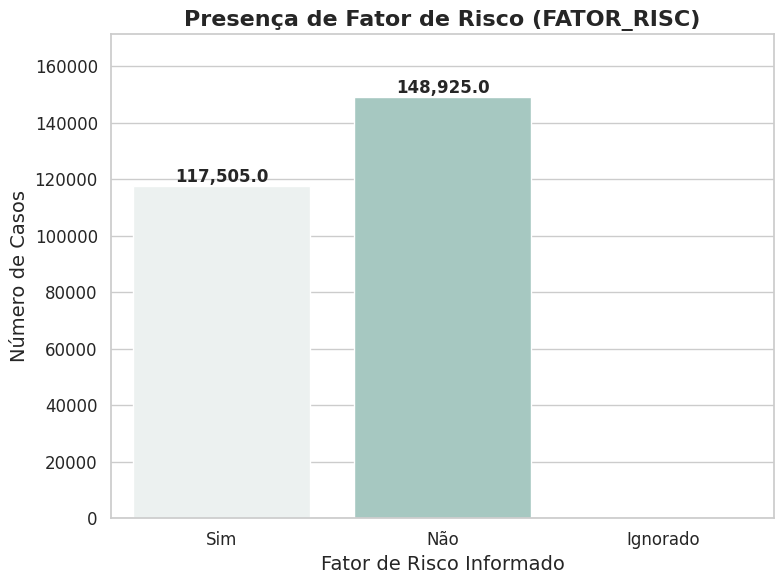

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Mapeamento dos códigos para texto
fator_risco_map = {
    1: 'Sim',
    2: 'Não',
    9: 'Ignorado'
}

# Aplicar mapeamento
df['FATOR_RISC_DESC'] = df['FATOR_RISC'].map(fator_risco_map)

# Contagem dos valores com ordem personalizada
order = ['Sim', 'Não', 'Ignorado']
counts = df['FATOR_RISC_DESC'].value_counts().reindex(order)

# Plot com estilo moderno
plt.figure(figsize=(8,6))
sns.set_style("whitegrid")
colors = sns.color_palette("light:#5A9", len(order))

barplot = sns.barplot(x=counts.index, y=counts.values, palette=colors)

# Adiciona os valores acima das barras
for i, v in enumerate(counts.values):
    barplot.text(i, v + max(counts.values)*0.01, f'{v:,}', ha='center', fontsize=12, weight='bold')

# Título e rótulos
plt.title('Presença de Fator de Risco (FATOR_RISC)', fontsize=16, weight='bold')
plt.xlabel('Fator de Risco Informado', fontsize=14)
plt.ylabel('Número de Casos', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()


# Análise cruzada com evolução (EVOLUCAO) para ver a relação entre fator de risco e óbito

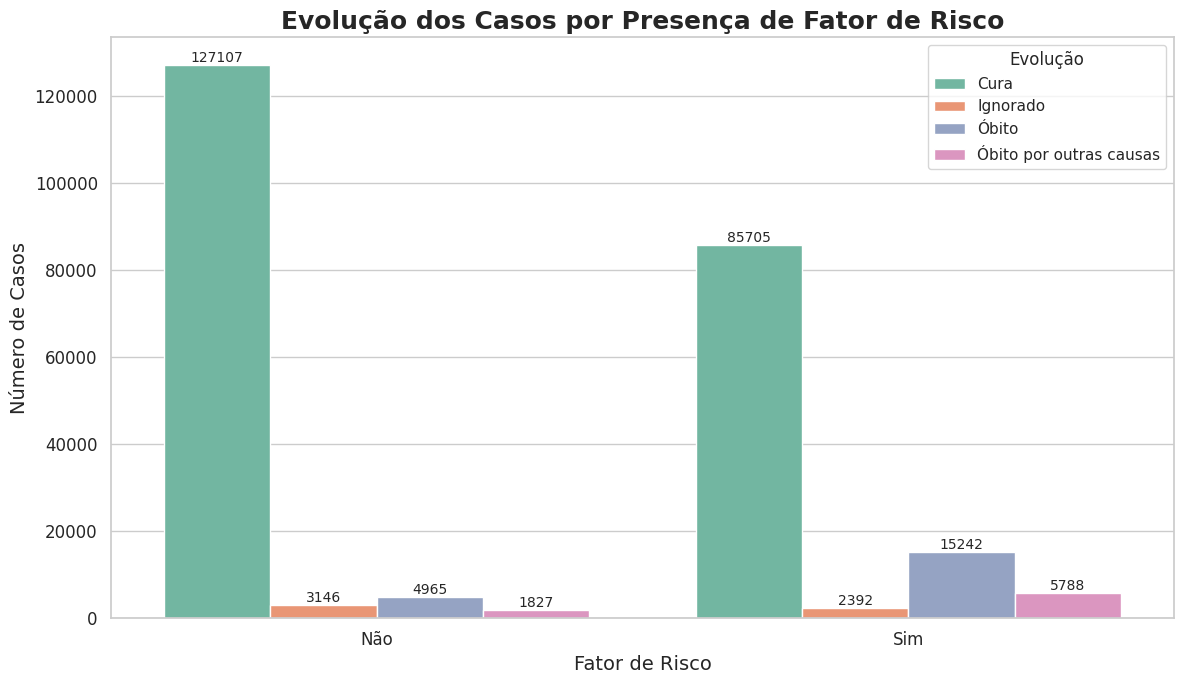

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Mapeamentos
fator_risco_map = {
    1: 'Sim',
    2: 'Não',
    9: 'Ignorado'
}

evolucao_map = {
    1: 'Cura',
    2: 'Óbito',
    3: 'Óbito por outras causas',
    9: 'Ignorado'
}

# Aplicar mapeamentos
df['FATOR_RISC_DESC'] = df['FATOR_RISC'].map(fator_risco_map)
df['EVOLUCAO_DESC'] = df['EVOLUCAO'].map(evolucao_map)

# Contagem cruzada
df_plot = df.groupby(['FATOR_RISC_DESC', 'EVOLUCAO_DESC']).size().reset_index(name='Total')

# Gráfico de barras agrupadas
plt.figure(figsize=(12,7))
sns.set_style("whitegrid")
barplot = sns.barplot(
    data=df_plot,
    x='FATOR_RISC_DESC',
    y='Total',
    hue='EVOLUCAO_DESC',
    palette='Set2'
)

# Adiciona rótulos nos topos das barras
for container in barplot.containers:
    barplot.bar_label(container, fmt='%d', label_type='edge', fontsize=10)

# Ajustes de layout
plt.title('Evolução dos Casos por Presença de Fator de Risco', fontsize=18, weight='bold')
plt.xlabel('Fator de Risco', fontsize=14)
plt.ylabel('Número de Casos', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Evolução', fontsize=11, title_fontsize=12)
plt.tight_layout()
plt.show()


# Gráfico de Sintomas Sim/Não (binários)

Selecionado os Sintomas (FEBRE,  TOSSE, GARGANTA, DISPNEIA , DESC_RESP, SATURACAO, DIARREIA, VOMITO, DOR_ABD , FADIGA, PERD_OLFT, PERD_PALA, OUTRO_SIN)

Onde:
1-Sim
2-Não
9-Ignorado


In [24]:
sintomas = [
    'FEBRE', 'TOSSE', 'GARGANTA', 'DISPNEIA', 'DESC_RESP', 'SATURACAO',
    'DIARREIA', 'VOMITO', 'DOR_ABD', 'FADIGA', 'PERD_OLFT', 'PERD_PALA', 'OUTRO_SIN'
]

# Rótulos amigáveis
labels = {
    'FEBRE': 'Febre',
    'TOSSE': 'Tosse',
    'GARGANTA': 'Dor de garganta',
    'DISPNEIA': 'Dispneia',
    'DESC_RESP': 'Desconforto respiratório',
    'SATURACAO': 'Sat. O2 < 95%',
    'DIARREIA': 'Diarreia',
    'VOMITO': 'Vômito',
    'DOR_ABD': 'Dor abdominal',
    'FADIGA': 'Fadiga',
    'PERD_OLFT': 'Perda olfato',
    'PERD_PALA': 'Perda paladar',
    'OUTRO_SIN': 'Outro sintoma (Sim/Não)'
}


<ipython-input-25-e07009c238b9>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


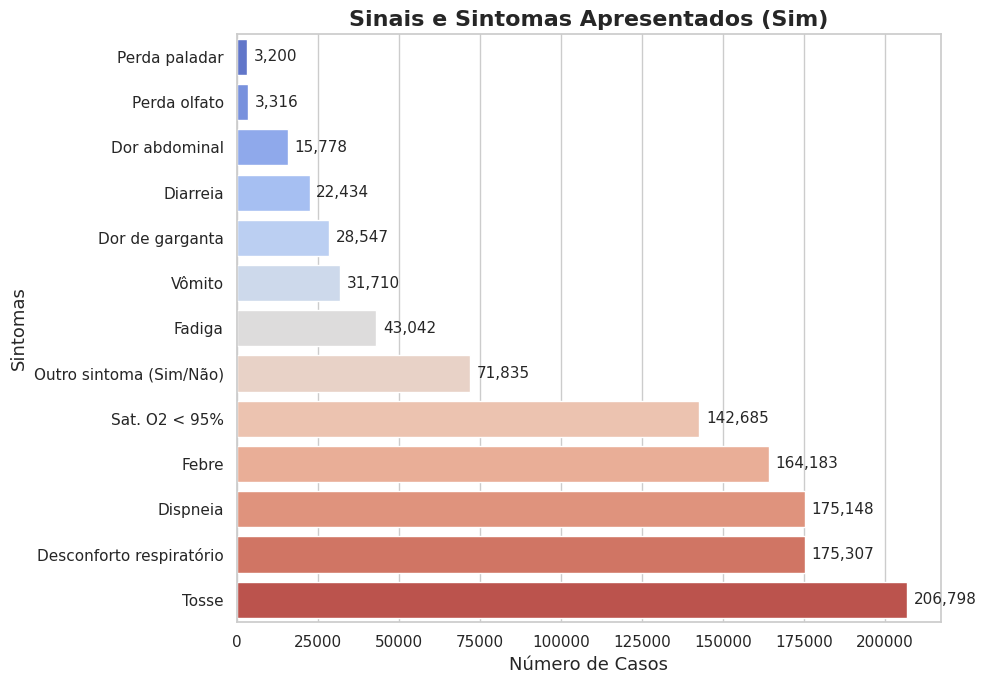

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contar quantos pacientes marcaram "1 - Sim" para cada sintoma
sintomas_sim = {col: (df[col] == 1).sum() for col in sintomas}

# Converter para DataFrame ordenado
df_sintomas = pd.DataFrame.from_dict(sintomas_sim, orient='index', columns=['Total'])
df_sintomas['Sintoma'] = df_sintomas.index.map(labels)
df_sintomas = df_sintomas.sort_values(by='Total', ascending=True)

# Plot horizontal
plt.figure(figsize=(10, 7))
sns.set_style("whitegrid")
barplot = sns.barplot(
    data=df_sintomas,
    y='Sintoma',
    x='Total',
    palette='coolwarm'
)

# Adicionar rótulos
for index, value in enumerate(df_sintomas['Total']):
    plt.text(value + df_sintomas['Total'].max() * 0.01, index, f'{value:,}', va='center', fontsize=11)

plt.title('Sinais e Sintomas Apresentados (Sim)', fontsize=16, weight='bold')
plt.xlabel('Número de Casos', fontsize=13)
plt.ylabel('Sintomas', fontsize=13)
plt.tight_layout()
plt.show()


# Nuvem de Palavras dos Sintomas Livres (OUTRO_DES)

OUTRO_DES:   Listar outros sinais  e  sintomas apresentados pelo paciente


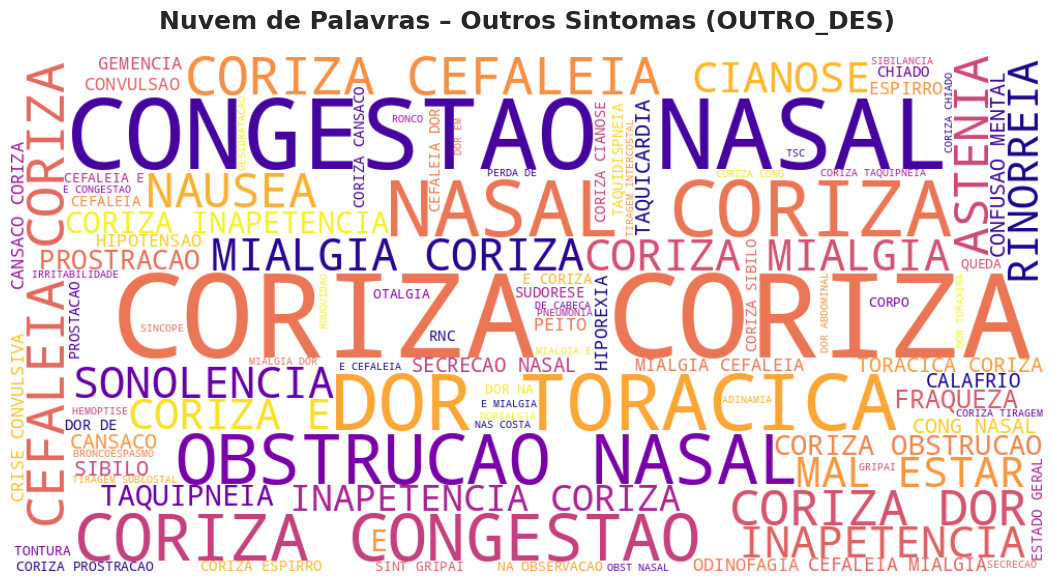

In [26]:
from wordcloud import WordCloud, STOPWORDS

# Remover valores nulos e vazios
texto_outros = df['OUTRO_DES'].dropna()
texto_outros = texto_outros[texto_outros.str.strip() != '']
texto = ' '.join(texto_outros.astype(str).tolist())

# Stopwords básicas
stopwords = set(STOPWORDS)
stopwords.update(['outro', 'sintoma', 'sintomas', 'não', 'apresenta'])

# Criar nuvem de palavras
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='plasma',
    max_words=100,
    stopwords=stopwords,
    contour_color='black'
).generate(texto)

# Mostrar nuvem
plt.figure(figsize=(14, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nuvem de Palavras – Outros Sintomas (OUTRO_DES)', fontsize=18, weight='bold', pad=20)
plt.tight_layout()
plt.show()


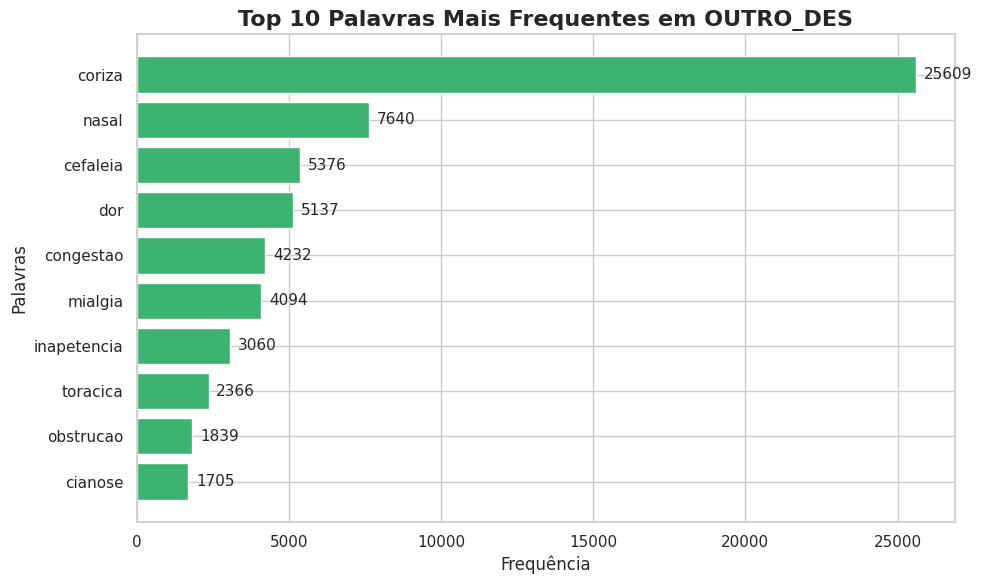

In [27]:
import matplotlib.pyplot as plt
from collections import Counter
import re
from wordcloud import STOPWORDS

# 1. Extrair textos não nulos e não vazios
outro_des_texts = df['OUTRO_DES'].dropna()
outro_des_texts = outro_des_texts[outro_des_texts.str.strip() != '']

# 2. Unir todos os textos em uma string só
texto = ' '.join(outro_des_texts.astype(str).tolist()).lower()

# 3. Limpeza básica: manter só letras e números, substituir outros por espaço
texto = re.sub(r'[^a-záéíóúãõç0-9\s]', ' ', texto)

# 4. Tokenizar (quebrar em palavras)
palavras = texto.split()

# 5. Remover stopwords em português e algumas específicas
stopwords = set(STOPWORDS)
stopwords.update([
    'outro', 'sintoma', 'sintomas', 'nao', 'sem', 'com', 'e', 'a', 'o', 'para', 'em', 'paciente',
    'pacientes', 'relatado', 'relatada', 'presente', 'presença'
])

palavras_filtradas = [p for p in palavras if p not in stopwords and len(p) > 2]

# 6. Contar frequência
freq_palavras = Counter(palavras_filtradas)

# 7. Top 10 palavras mais comuns
top_10 = freq_palavras.most_common(10)

# 8. Preparar para plot
palavras_top10 = [p[0] for p in top_10]
contagens_top10 = [p[1] for p in top_10]

# Plot gráfico
plt.figure(figsize=(10,6))
bars = plt.barh(palavras_top10[::-1], contagens_top10[::-1], color='mediumseagreen')
plt.title('Top 10 Palavras Mais Frequentes em OUTRO_DES', fontsize=16, weight='bold')
plt.xlabel('Frequência')
plt.ylabel('Palavras')

# Adicionar número na frente das barras
for bar in bars:
    largura = bar.get_width()
    plt.text(largura + max(contagens_top10)*0.01, bar.get_y() + bar.get_height()/2, f'{int(largura)}',
             va='center', fontsize=11)

plt.tight_layout()
plt.show()


# Fatores de Risco
Selecionado os fatores de Risco (PUERPERA, CARDIOPATI,HEMATOLOGI, SIND_DOWN, HEPATICA, ASMA , DIABETES , NEUROLOGIC , PNEUMOPATI , IMUNODEPRE, RENAL, OBESIDADE, OUT_MORBI)
Onde:
1-Sim
2-Não
9-Ignorado

* OBES_IMC: Valor do IMC (Índice de Massa Corporal) do paciente calculado pelo profissional de saúde

* MORB_DESC: Listar outro(s) fator(es) de risco do paciente




In [28]:
fatores_binarios = [
    'PUERPERA', 'CARDIOPATI', 'HEMATOLOGI', 'SIND_DOWN', 'HEPATICA',
    'ASMA', 'DIABETES', 'NEUROLOGIC', 'PNEUMOPATI', 'IMUNODEPRE',
    'RENAL', 'OBESIDADE', 'OUT_MORBI'
]

# Nomes legíveis
fatores_labels = {
    'PUERPERA': 'Puérpera',
    'CARDIOPATI': 'Cardiopatia',
    'HEMATOLOGI': 'Doença hematológica',
    'SIND_DOWN': 'Síndrome de Down',
    'HEPATICA': 'Doença hepática',
    'ASMA': 'Asma',
    'DIABETES': 'Diabetes',
    'NEUROLOGIC': 'Doença neurológica',
    'PNEUMOPATI': 'Doença pulmonar crônica',
    'IMUNODEPRE': 'Imunodepressão',
    'RENAL': 'Doença renal crônica',
    'OBESIDADE': 'Obesidade',
    'OUT_MORBI': 'Outro fator de risco (sim/não)'
}


<ipython-input-29-8cb3d9e00694>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(data=df_fatores, y='Fator', x='Total', palette='crest')


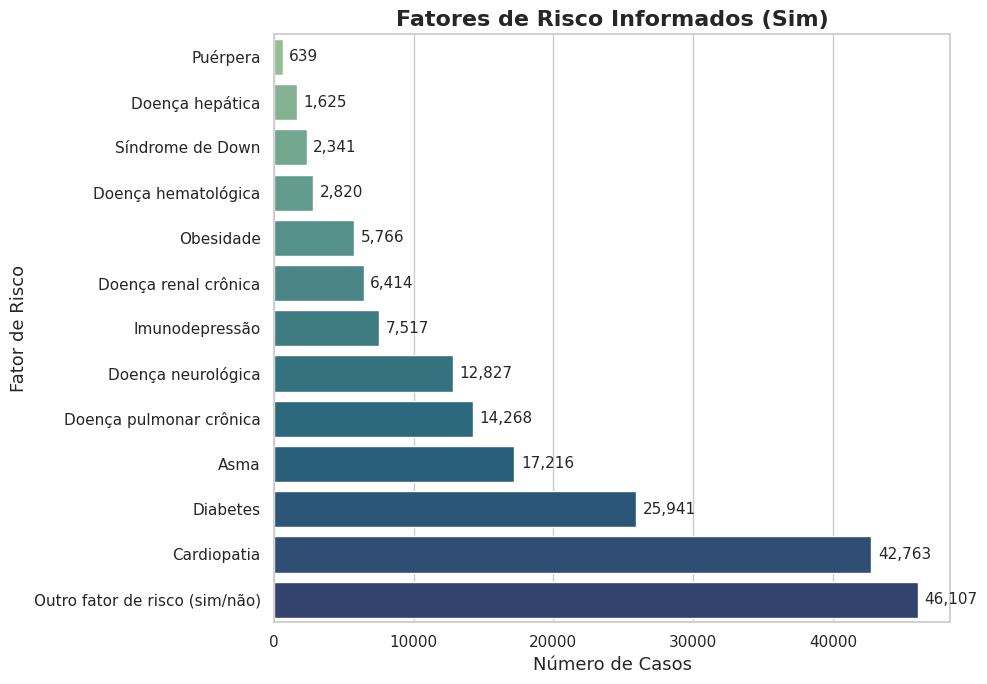

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contar "Sim" (1) em cada fator
fatores_sim = {col: (df[col] == 1).sum() for col in fatores_binarios}

# DataFrame ordenado
df_fatores = pd.DataFrame.from_dict(fatores_sim, orient='index', columns=['Total'])
df_fatores['Fator'] = df_fatores.index.map(fatores_labels)
df_fatores = df_fatores.sort_values(by='Total', ascending=True)

# Plot
plt.figure(figsize=(10, 7))
sns.set_style("whitegrid")
barplot = sns.barplot(data=df_fatores, y='Fator', x='Total', palette='crest')

# Rótulos
for i, v in enumerate(df_fatores['Total']):
    plt.text(v + df_fatores['Total'].max() * 0.01, i, f'{v:,}', va='center', fontsize=11)

plt.title('Fatores de Risco Informados (Sim)', fontsize=16, weight='bold')
plt.xlabel('Número de Casos', fontsize=13)
plt.ylabel('Fator de Risco', fontsize=13)
plt.tight_layout()
plt.show()


Histograma do IMC (OBES_IMC)

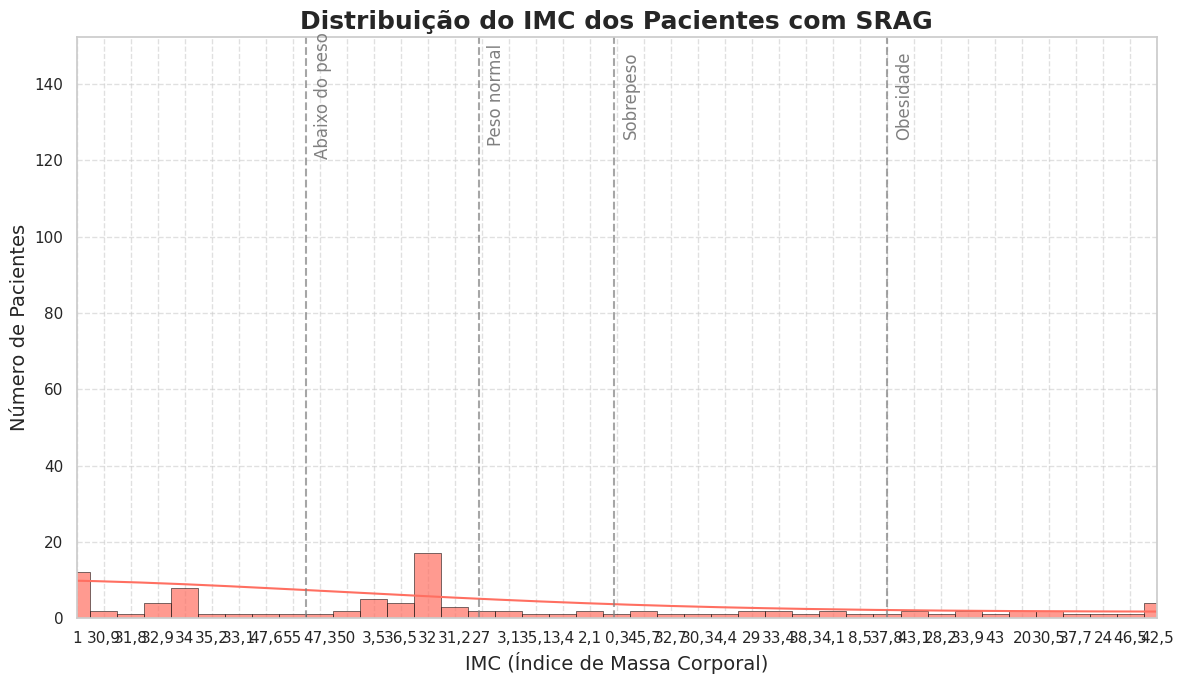

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(12,7))
sns.set_style("whitegrid")

# Histograma com KDE, cor agradável
sns.histplot(df['OBES_IMC'].dropna(), bins=30, kde=True, color='#FF6F61', edgecolor='black', alpha=0.7)

# Títulos e labels
plt.title('Distribuição do IMC dos Pacientes com SRAG', fontsize=18, weight='bold')
plt.xlabel('IMC (Índice de Massa Corporal)', fontsize=14)
plt.ylabel('Número de Pacientes', fontsize=14)

# Limites do eixo x e linhas de referência para categorias padrão de IMC
plt.xlim(10, 50)
imc_categorias = {
    'Abaixo do peso': 18.5,
    'Peso normal': 24.9,
    'Sobrepeso': 29.9,
    'Obesidade': 40
}
for cat, val in imc_categorias.items():
    plt.axvline(val, color='gray', linestyle='--', alpha=0.7)
    plt.text(val + 0.3, plt.ylim()[1]*0.9, cat, rotation=90, color='gray', fontsize=12, verticalalignment='center')

# Melhor grid e layout
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()


Nuvem de Palavras com MORB_DESC

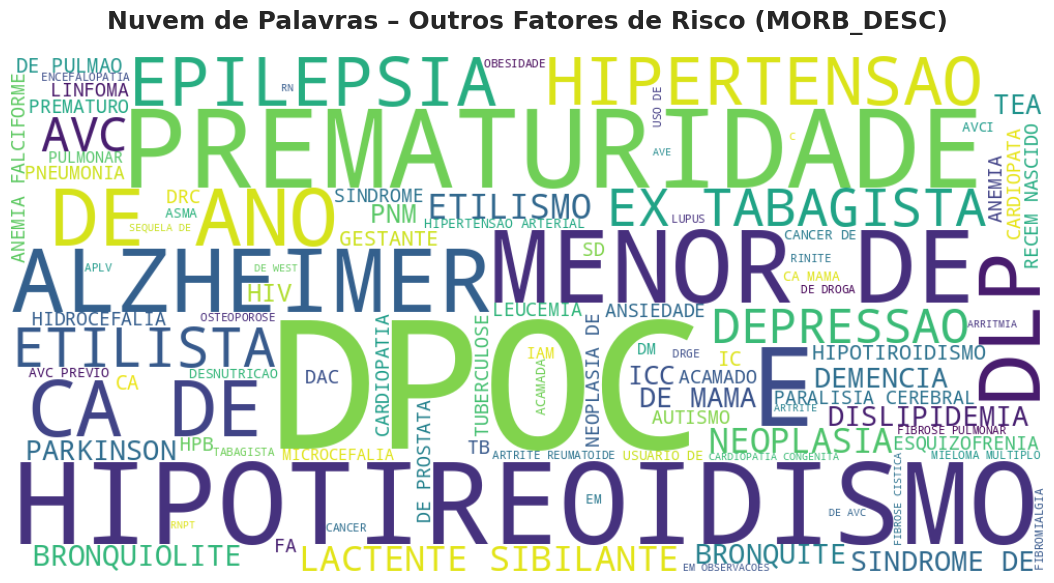

In [31]:
from wordcloud import WordCloud, STOPWORDS

# Texto dos outros fatores de risco
morbi_text = df['MORB_DESC'].dropna()
morbi_text = morbi_text[morbi_text.str.strip() != '']
texto_morbi = ' '.join(morbi_text.astype(str).tolist())

# Stopwords
stopwords = set(STOPWORDS)
stopwords.update(['outro', 'doenca', 'cronica', 'nao', 'apresenta'])

# WordCloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='viridis',
    max_words=100,
    stopwords=stopwords
).generate(texto_morbi)

plt.figure(figsize=(14, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nuvem de Palavras – Outros Fatores de Risco (MORB_DESC)', fontsize=18, weight='bold', pad=20)
plt.tight_layout()
plt.show()


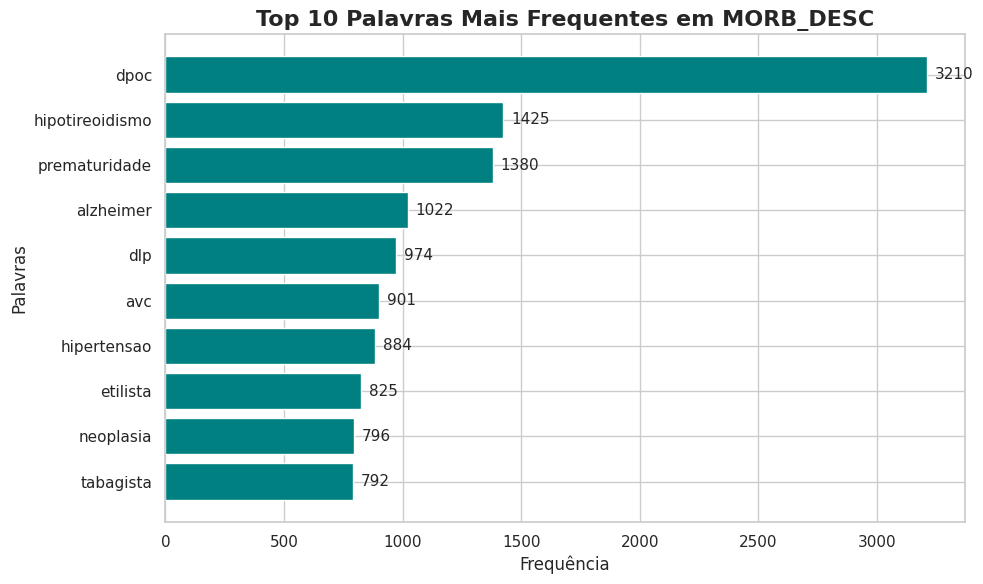

In [54]:
import matplotlib.pyplot as plt
from collections import Counter
import re
from wordcloud import STOPWORDS

# 1. Extrair textos não nulos e não vazios
morbi_texts = df['MORB_DESC'].dropna()
morbi_texts = morbi_texts[morbi_texts.str.strip() != '']

# 2. Unir todos os textos em uma string só
texto = ' '.join(morbi_texts.astype(str).tolist()).lower()

# 3. Limpeza básica: manter só letras e números, substituir outros por espaço
texto = re.sub(r'[^a-záéíóúãõç0-9\s]', ' ', texto)

# 4. Tokenizar (quebrar em palavras)
palavras = texto.split()

# 5. Remover stopwords em português e algumas específicas
stopwords = set(STOPWORDS)
stopwords.update([
    'outro', 'fator', 'de', 'risco', 'doença', 'doenca', 'cronica', 'cronico',
    'nao', 'sem', 'com', 'e', 'a', 'o', 'para', 'em', 'paciente', 'pacientes',
    'comorbidade', 'crônica', 'crônico', 'menor', 'anos'
])

palavras_filtradas = [p for p in palavras if p not in stopwords and len(p) > 2]

# 6. Contar frequência
freq_palavras = Counter(palavras_filtradas)

# 7. Top 10 palavras mais comuns
top_10 = freq_palavras.most_common(10)

# 8. Preparar para plot
palavras_top10 = [p[0] for p in top_10]
contagens_top10 = [p[1] for p in top_10]

# Plot gráfico
plt.figure(figsize=(10,6))
bars = plt.barh(palavras_top10[::-1], contagens_top10[::-1], color='teal')
plt.title('Top 10 Palavras Mais Frequentes em MORB_DESC', fontsize=16, weight='bold')
plt.xlabel('Frequência')
plt.ylabel('Palavras')

# Adicionar número na frente das barras
for bar in bars:
    largura = bar.get_width()
    plt.text(largura + max(contagens_top10)*0.01, bar.get_y() + bar.get_height()/2, f'{int(largura)}',
             va='center', fontsize=11)

plt.tight_layout()
plt.show()



## Numero de Casos por Estado


In [33]:
import folium
import geopandas as gpd
import pandas as pd
import json
import requests
from branca.colormap import linear

# Carregar o shapefile dos estados brasileiros (basta fazer upload ou usar um repositório público)
url_shapefile = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"

# Baixar e carregar o GeoJSON
response = requests.get(url_shapefile)
geojson_data = response.json()

In [34]:
# Contar os casos por estado
casos_por_estado = df["SG_UF_NOT"].value_counts().reset_index()
casos_por_estado.columns = ["Estado", "Casos"]

In [35]:
# Criar um dicionário para mapear estados aos valores
casos_dict = dict(zip(casos_por_estado["Estado"], casos_por_estado["Casos"]))

# Criar um mapa centrado no Brasil
mapa = folium.Map(location=[-14.2350, -51.9253], zoom_start=4)

In [36]:
# Criar um colormap para as cores do mapa
colormap = linear.YlOrRd_09.scale(min(casos_dict.values()), max(casos_dict.values()))

In [37]:
def get_estado_sigla(feature):
    """ Retorna a sigla do estado ou None se não existir. """
    return feature["properties"].get("sigla", None)

In [38]:
# Adicionar os estados ao mapa
folium.GeoJson(
    geojson_data,
    name="Casos por Estado",
    style_function=lambda feature: {
        "fillColor": colormap(casos_dict.get(get_estado_sigla(feature), 0)),
        "color": "black",
        "weight": 1,
        "fillOpacity": 0.7,
    },
    tooltip=folium.GeoJsonTooltip(fields=["name"], aliases=["Estado"]),
).add_to(mapa)


In [39]:
# Adicionar a legenda
colormap.caption = "Número de Casos por Estado"
colormap.add_to(mapa)

In [40]:
mapa

# Criando Correlações
## Sintomas vs EVOLUÇÃO

In [41]:
# 🚀 1. Instalações e importações
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

sns.set(style='whitegrid')


📌 Sintoma: FEBRE


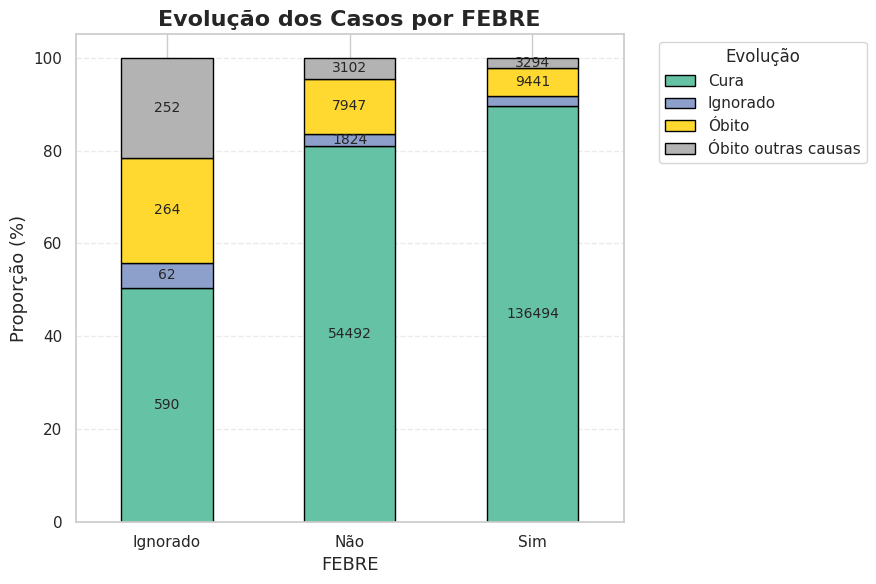

📊 Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa

📌 Sintoma: TOSSE


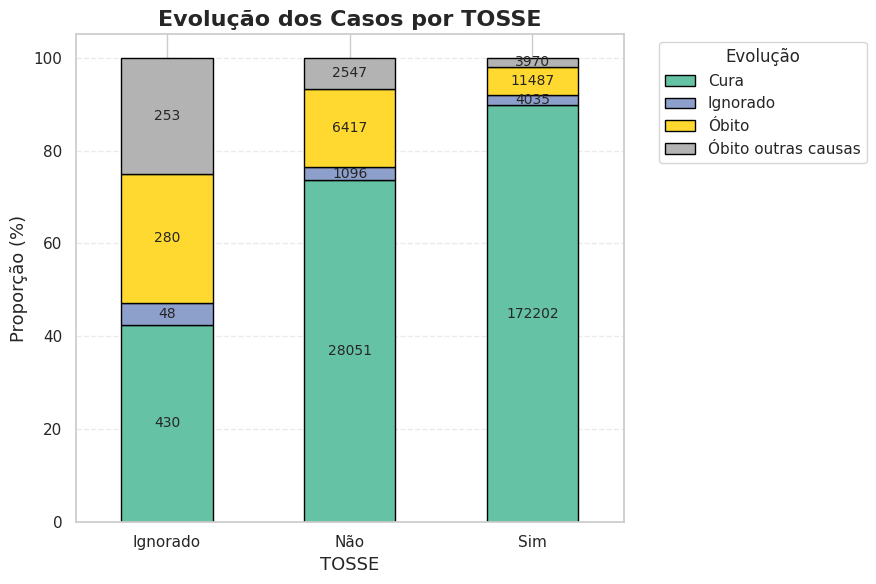

📊 Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa

📌 Sintoma: DISPNEIA


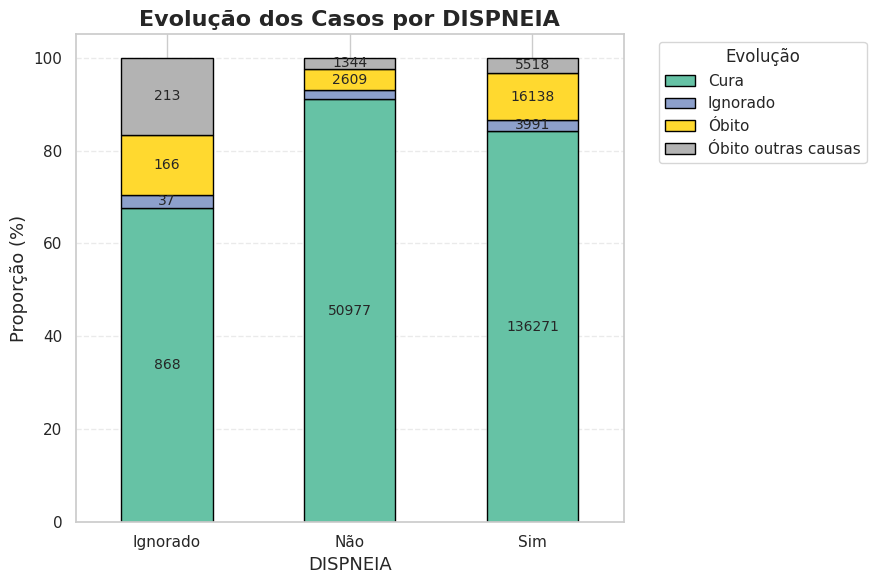

📊 Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa

📌 Sintoma: GARGANTA


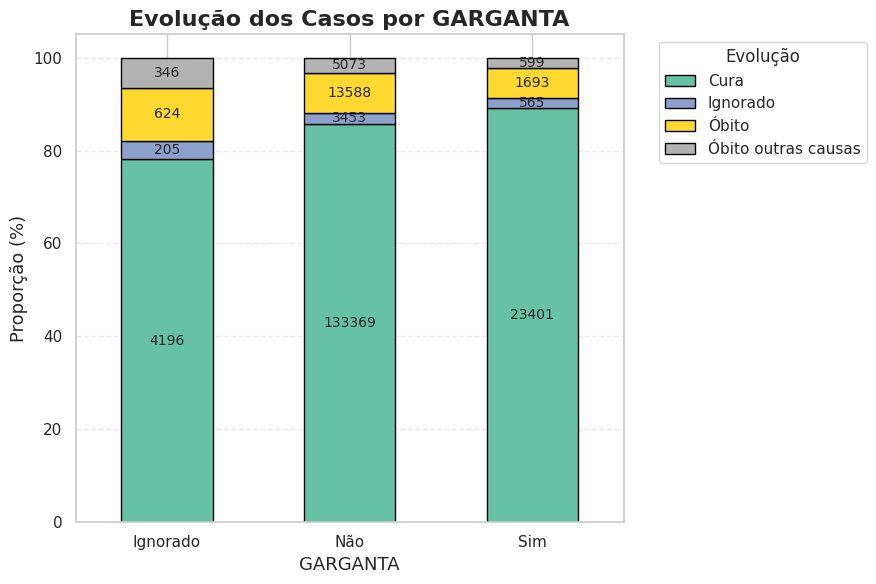

📊 Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa

📌 Sintoma: SATURACAO


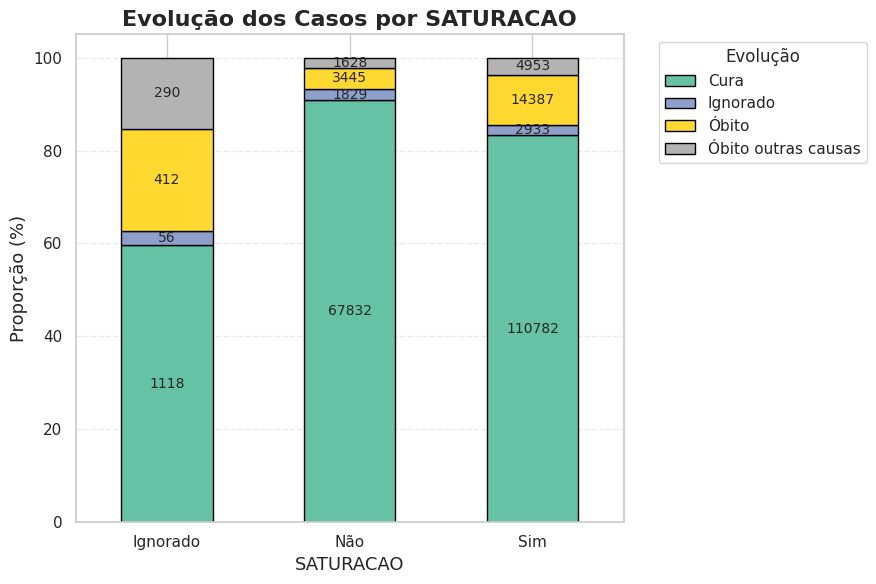

📊 Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa

📌 Fator de Risco: PUERPERA


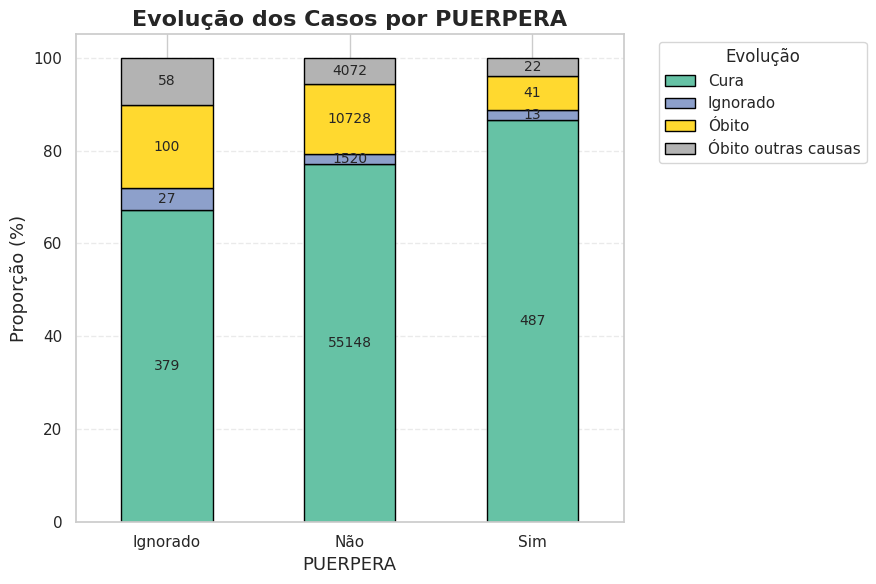

📊 Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa

📌 Fator de Risco: CARDIOPATI


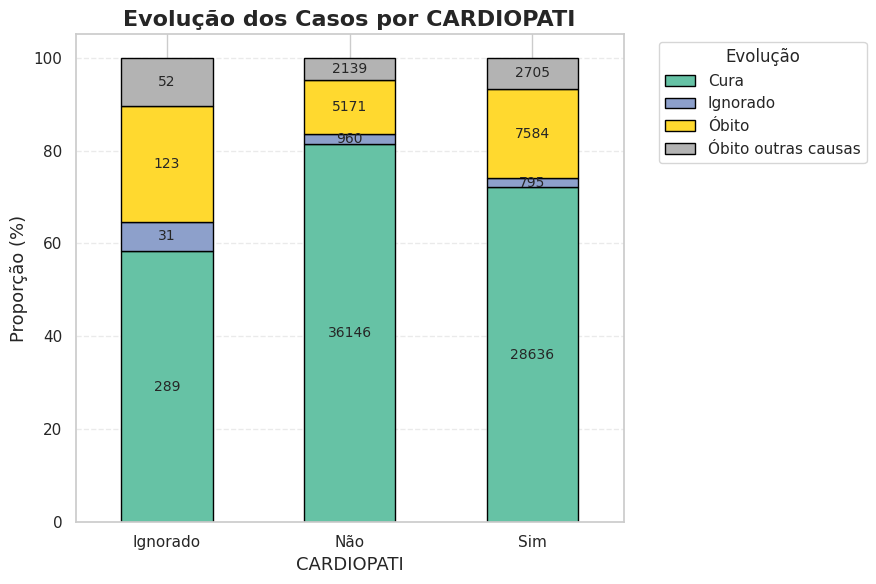

📊 Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa

📌 Fator de Risco: DIABETES


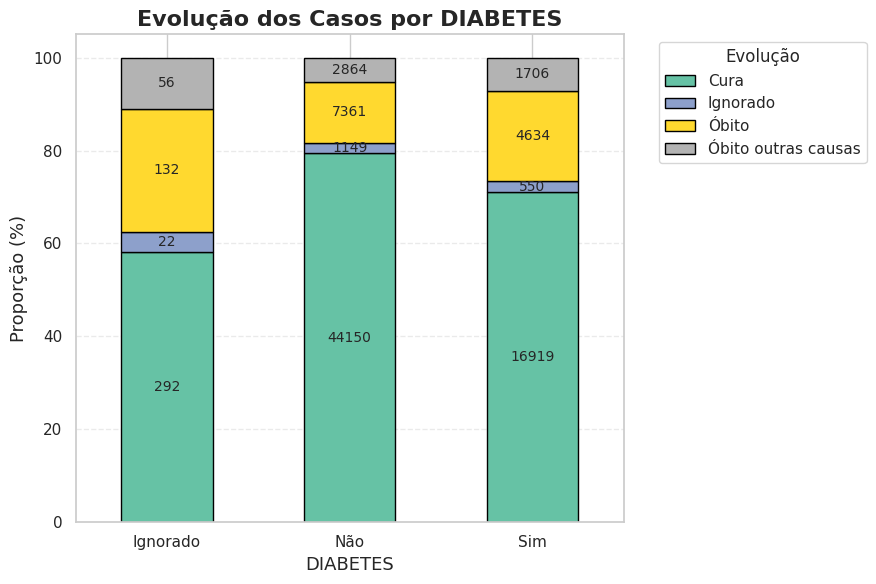

📊 Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa

📌 Fator de Risco: OBESIDADE


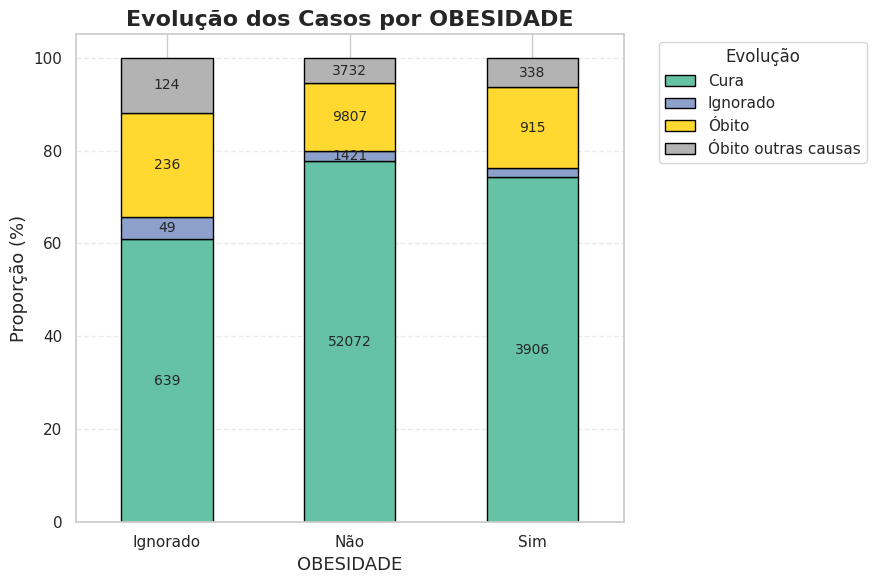

📊 Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa

📌 Fator de Risco: IMUNODEPRE


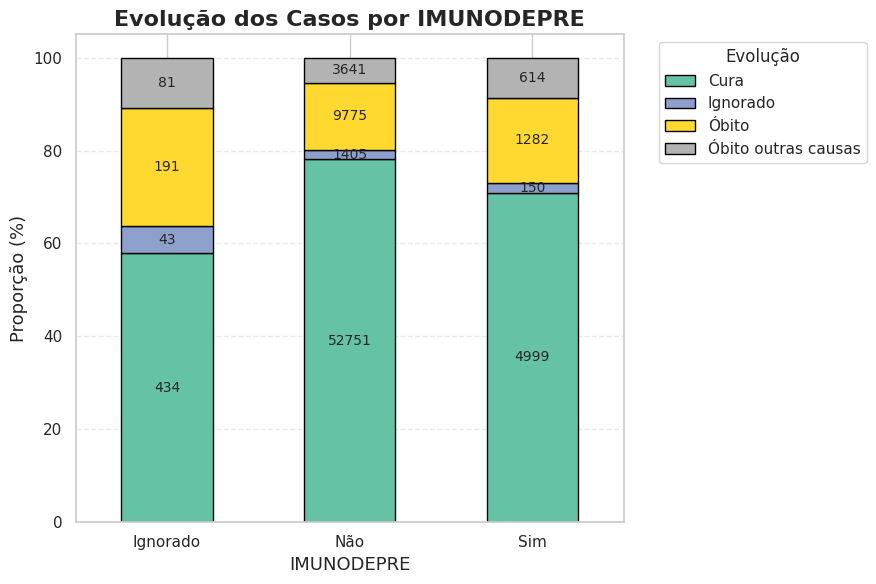

📊 Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa

📌 Fator de Risco: RENAL


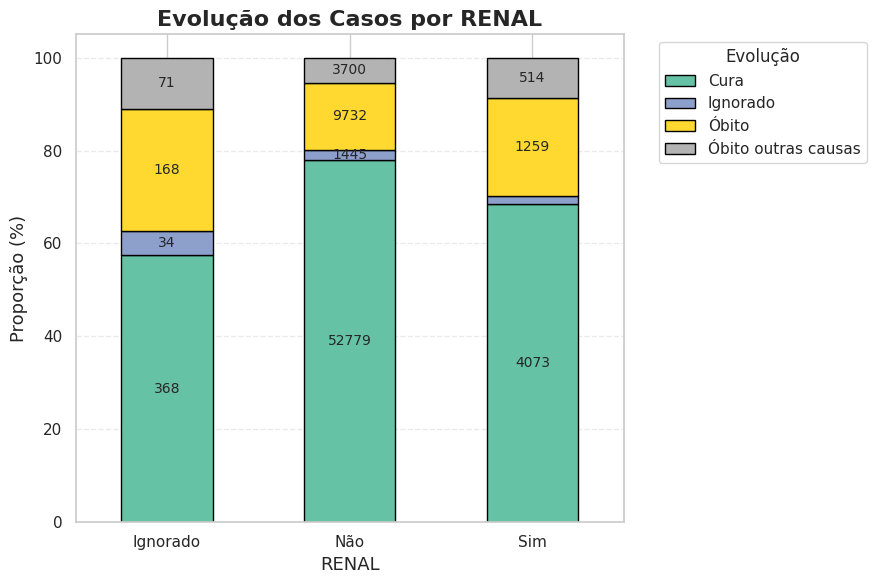

📊 Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa


In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
df_copy = df
# Mapear EVOLUCAO
df_copy['EVOLUCAO'] = df_copy['EVOLUCAO'].map({
    1: 'Cura',
    2: 'Óbito',
    3: 'Óbito outras causas',
    9: 'Ignorado'
})

# Mapa binário
mapa_binario = {1: 'Sim', 2: 'Não', 9: 'Ignorado'}

# Fatores de risco e sintomas
fatores_risco = ['PUERPERA', 'CARDIOPATI', 'DIABETES', 'OBESIDADE', 'IMUNODEPRE', 'RENAL']
sintomas = ['FEBRE', 'TOSSE', 'DISPNEIA', 'GARGANTA', 'SATURACAO']

# Aplicar mapeamento
for col in fatores_risco + sintomas:
    if col in df_copy.columns:
        df_copy[col] = df_copy[col].map(mapa_binario)

# Função para cruzamento com validação extra
def plot_crosstab_annotated(col, evol='EVOLUCAO'):
    if col not in df_copy.columns:
        print(f"⚠️ Coluna '{col}' não encontrada.")
        return

    sub_df_copy = df_copy[[col, evol]].dropna()
    unique_vals = sub_df_copy[col].dropna().unique()

    if len(unique_vals) < 2:
        print(f"⚠️ Coluna {col} não possui dados suficientes para plotar.")
        return

    # Tabelas
    crosstab_pct = pd.crosstab(sub_df_copy[col], sub_df_copy[evol], normalize='index') * 100
    crosstab_abs = pd.crosstab(sub_df_copy[col], sub_df_copy[evol])

    ax = crosstab_pct.plot(kind='bar', stacked=True, colormap='Set2', figsize=(9,6), edgecolor='black')
    plt.title(f'Evolução dos Casos por {col}', fontsize=16, weight='bold')
    plt.ylabel('Proporção (%)', fontsize=13)
    plt.xlabel(col, fontsize=13)
    plt.xticks(rotation=0)
    plt.legend(title='Evolução', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Anotar valores
    for i, row in enumerate(crosstab_pct.values):
        cumulative = 0
        for j, pct in enumerate(row):
            count = crosstab_abs.iloc[i, j]
            if pct > 2:
                ax.text(i, cumulative + pct / 2, f'{count}', ha='center', va='center', fontsize=10)
            cumulative += pct

    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.show()

    # Teste Qui-Quadrado
    if crosstab_abs.shape[0] > 1 and crosstab_abs.shape[1] > 1:
        chi2, p, dof, expected = chi2_contingency(crosstab_abs)
        print(f'📊 Teste Qui-Quadrado: p = {p:.4f} {"✅ Associação significativa" if p < 0.05 else "❌ Sem associação significativa"}')
    else:
        print(f'⚠️ Dados insuficientes para teste qui-quadrado.')

# Rodar para sintomas
for col in sintomas:
    print(f'\n📌 Sintoma: {col}')
    plot_crosstab_annotated(col)

# Rodar para fatores de risco
for col in fatores_risco:
    print(f'\n📌 Fator de Risco: {col}')
    plot_crosstab_annotated(col)


## FATORES DE RISCO vs EVOLUÇÃO

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency


📌 PUERPERA


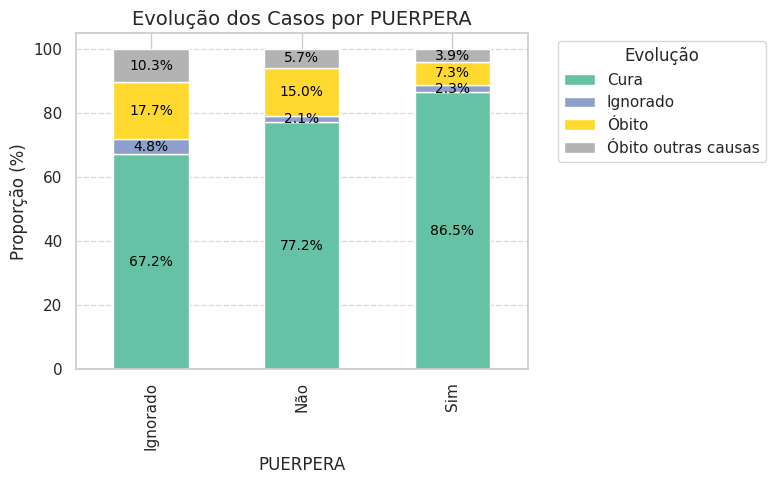

➡️ Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa

📌 CARDIOPATI


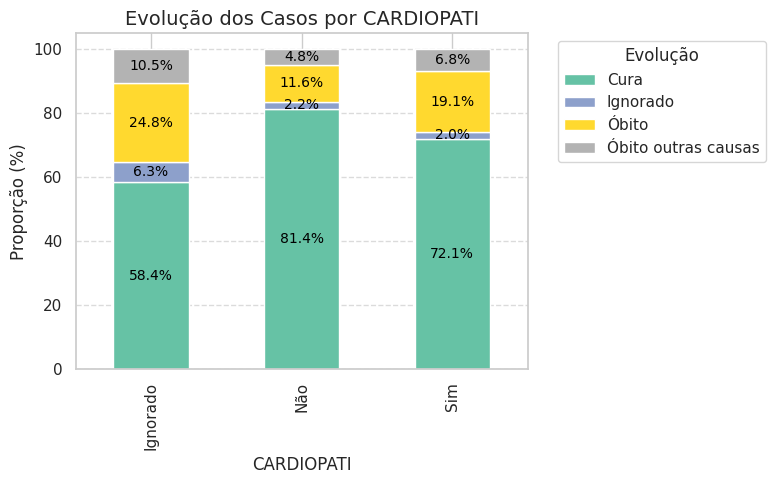

➡️ Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa

📌 HEMATOLOGI


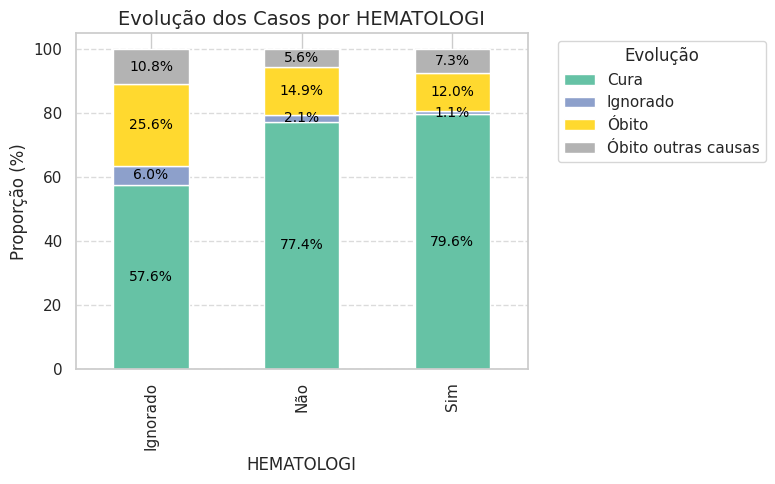

➡️ Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa

📌 SIND_DOWN


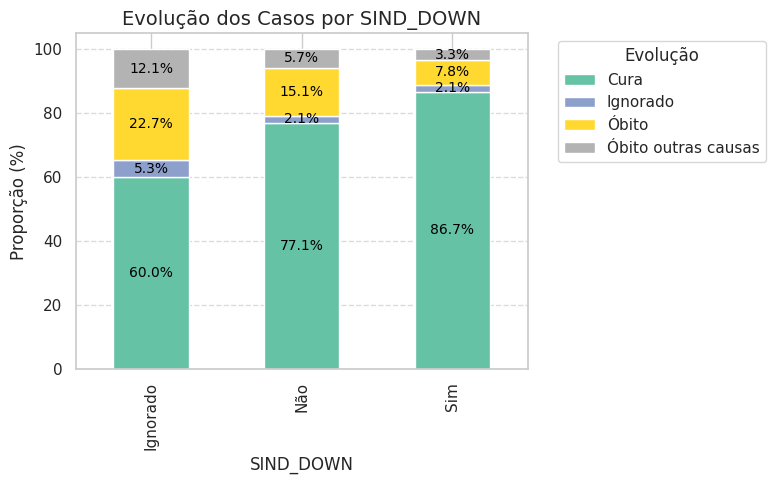

➡️ Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa

📌 HEPATICA


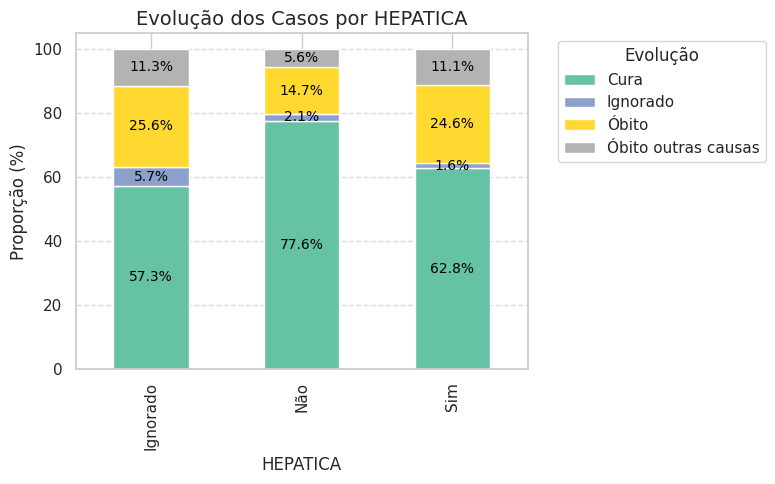

➡️ Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa

📌 ASMA


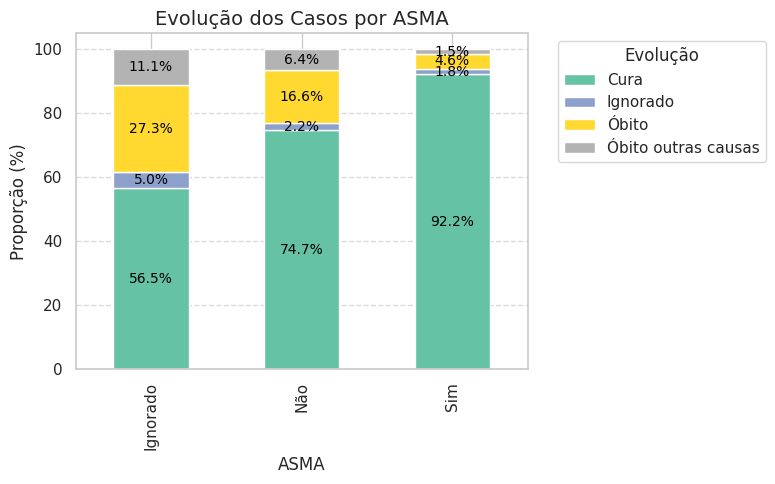

➡️ Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa

📌 DIABETES


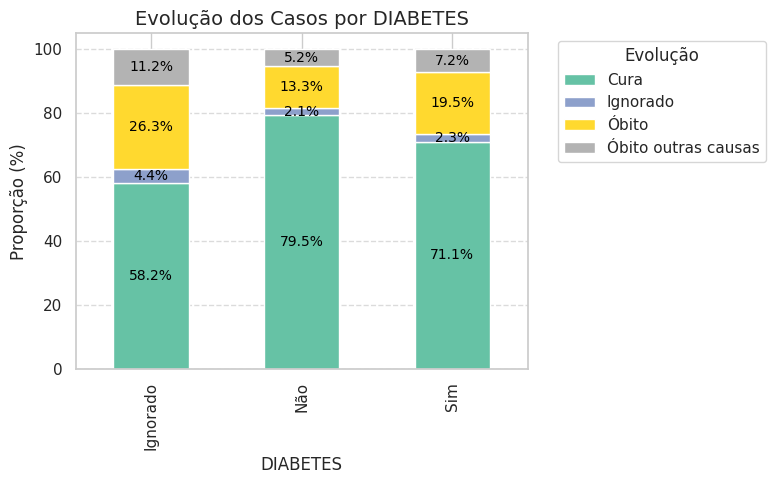

➡️ Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa

📌 NEUROLOGIC


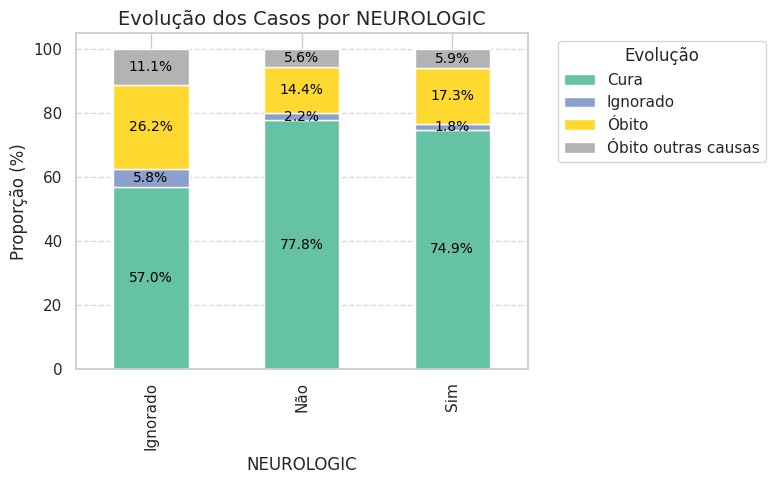

➡️ Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa

📌 PNEUMOPATI


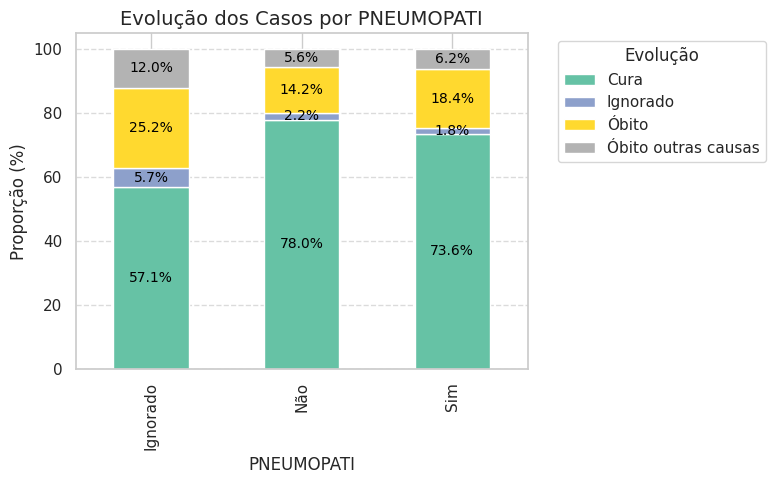

➡️ Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa

📌 IMUNODEPRE


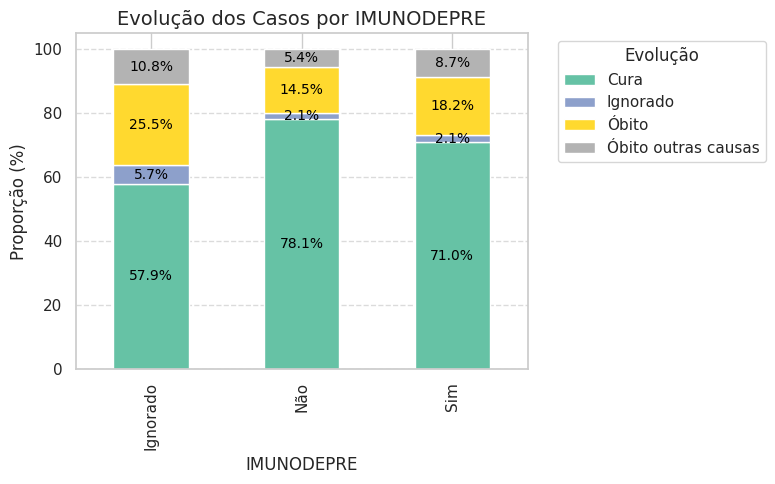

➡️ Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa

📌 RENAL


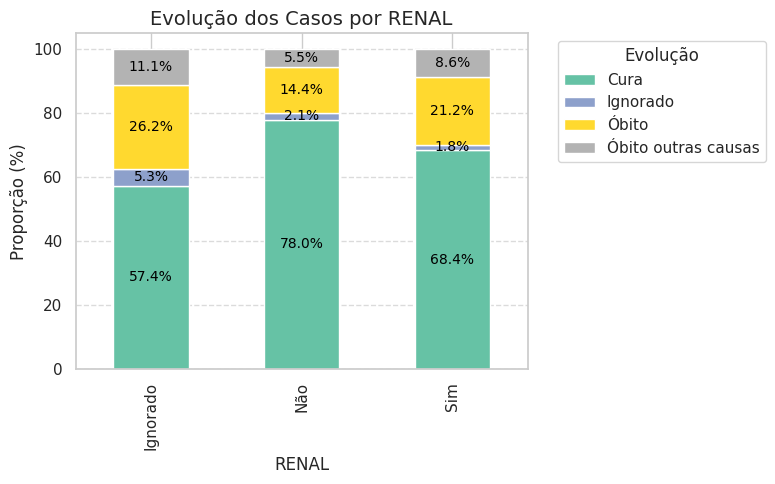

➡️ Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa

📌 OBESIDADE


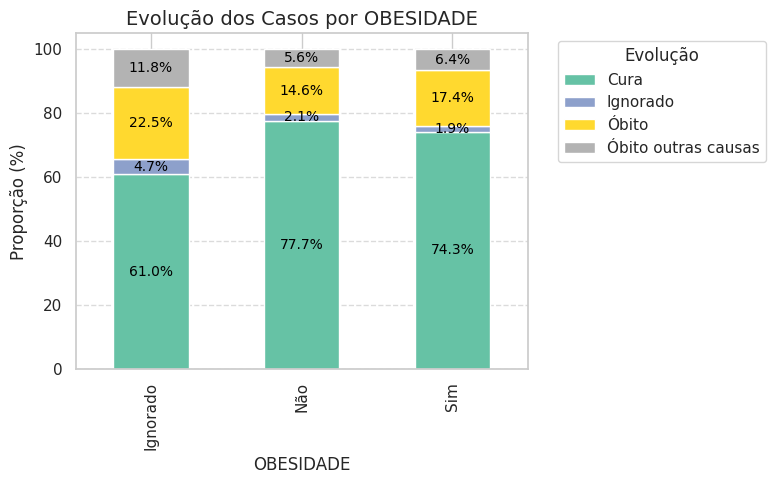

➡️ Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa

📌 OUT_MORBI


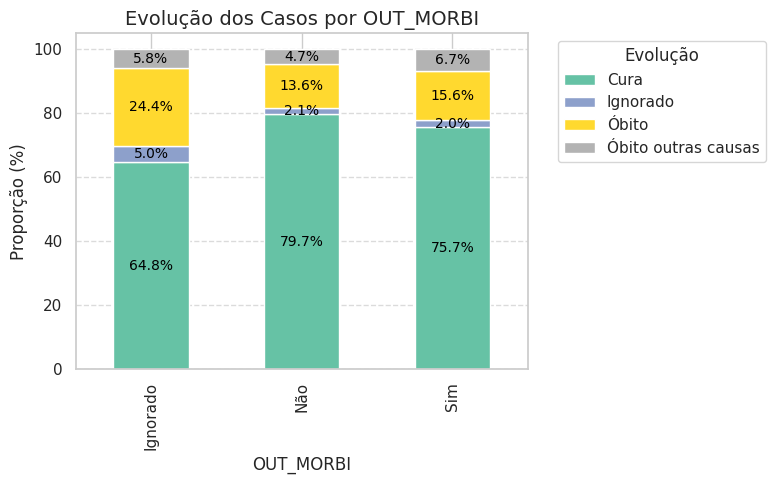

➡️ Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa

📌 FEBRE


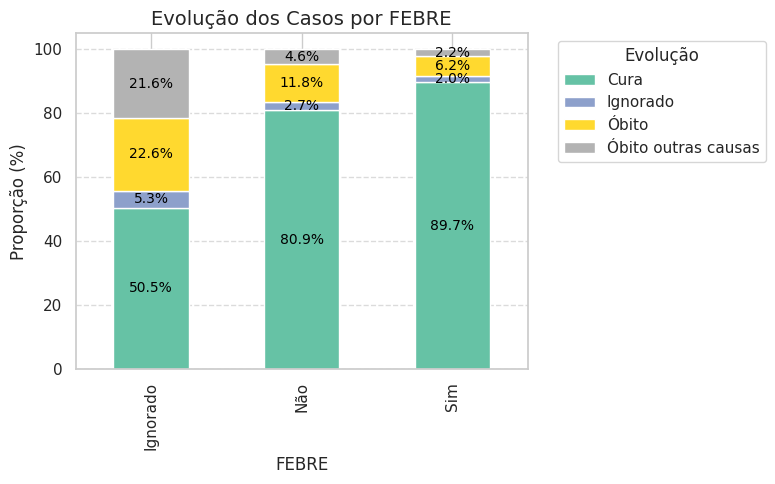

➡️ Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa

📌 TOSSE


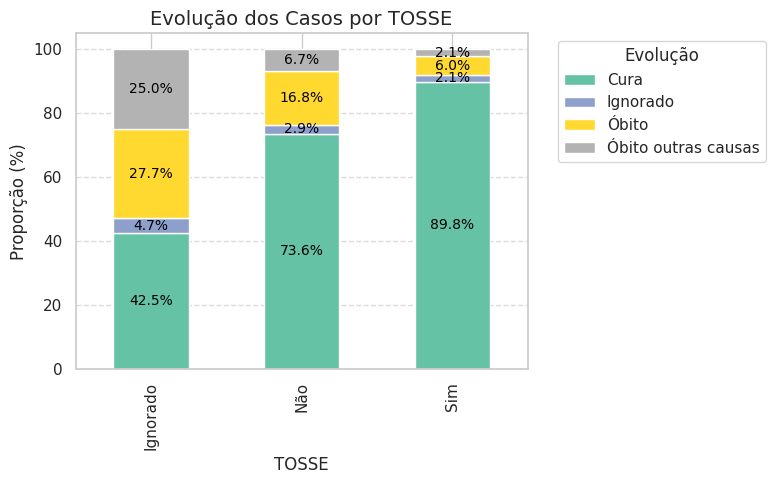

➡️ Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa

📌 GARGANTA


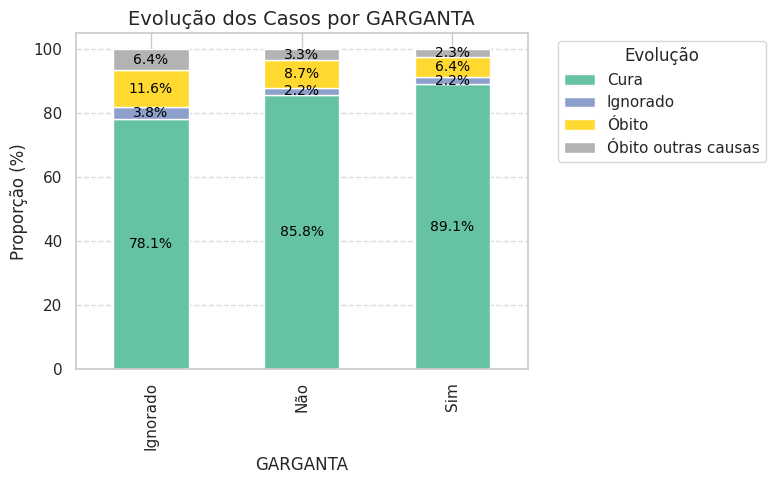

➡️ Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa

📌 DISPNEIA


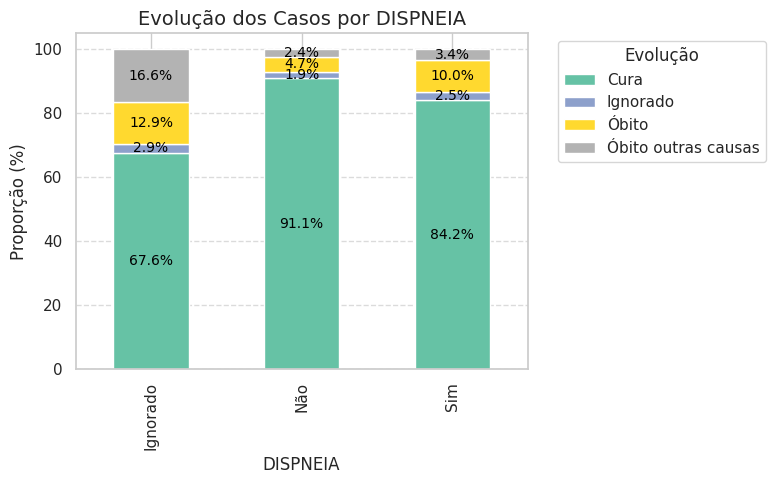

➡️ Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa

📌 DESC_RESP


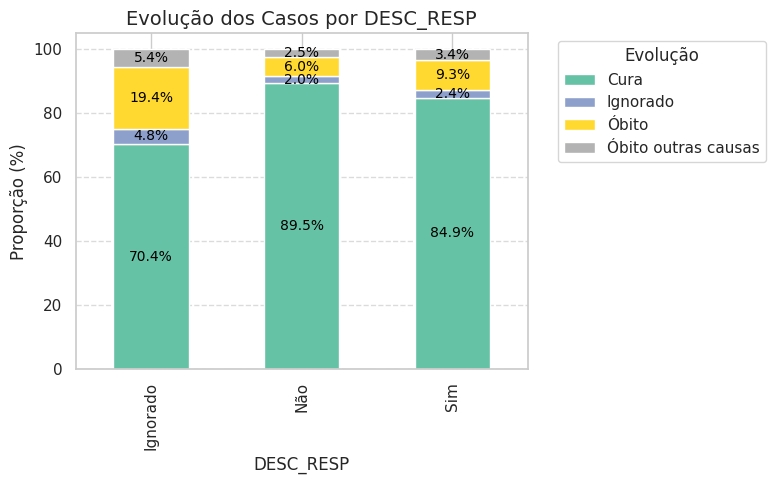

➡️ Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa

📌 SATURACAO


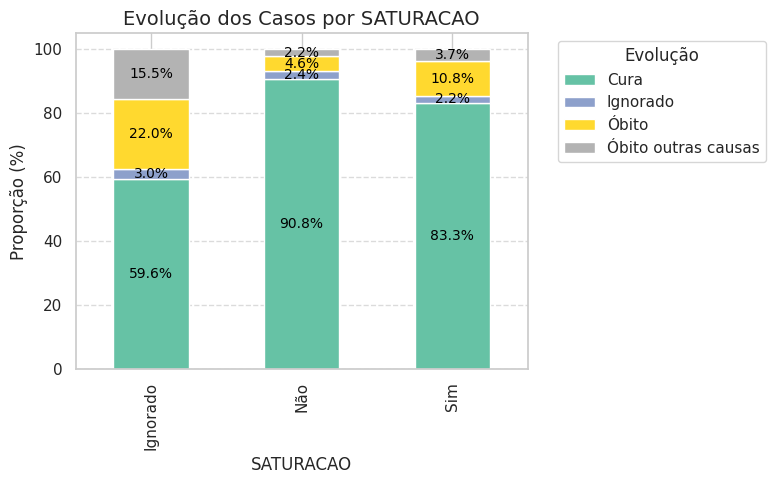

➡️ Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa

📌 DIARREIA


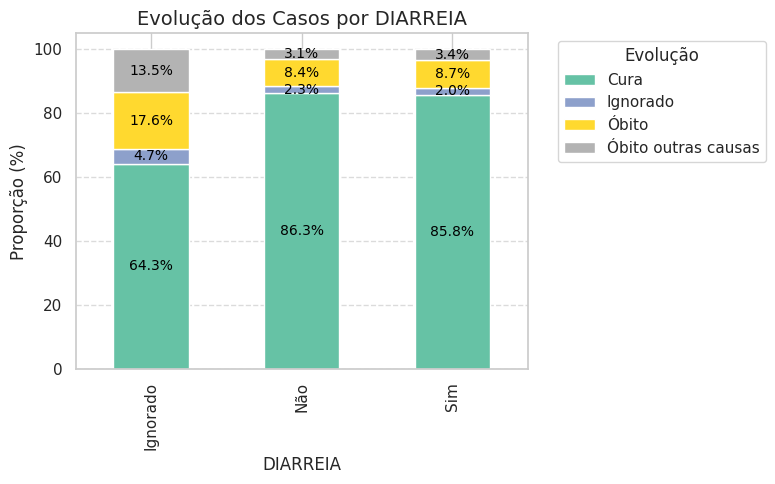

➡️ Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa

📌 VOMITO


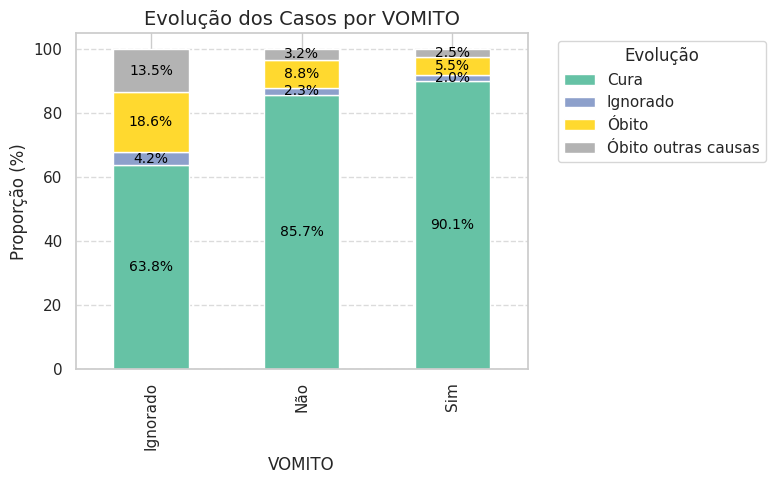

➡️ Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa

📌 DOR_ABD


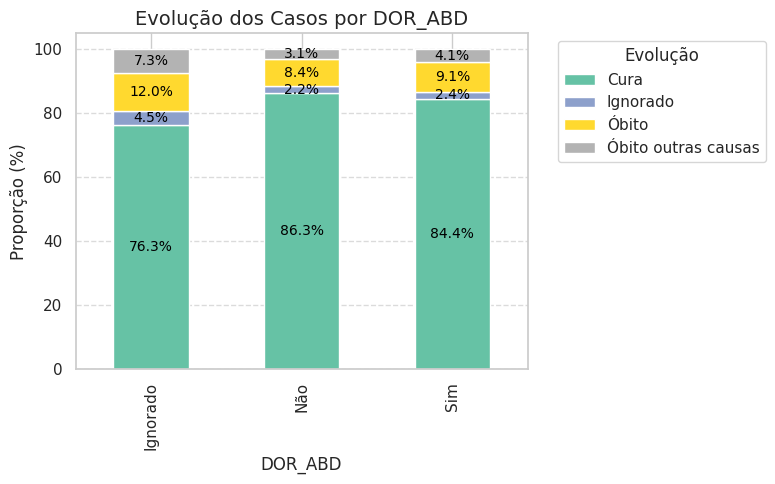

➡️ Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa

📌 FADIGA


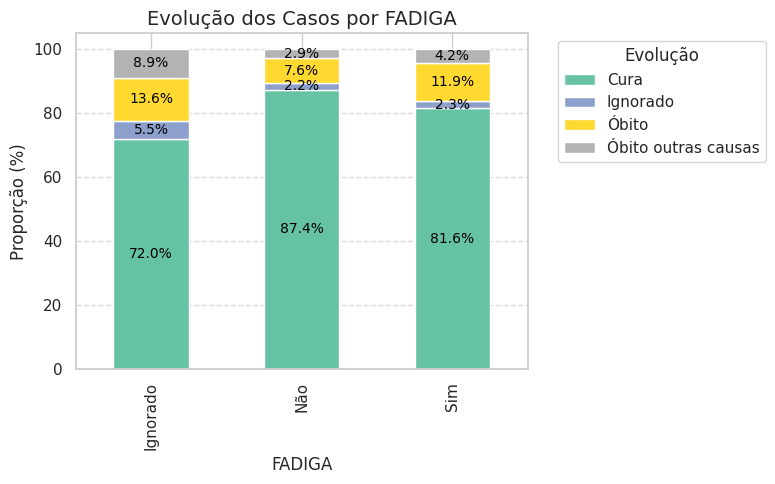

➡️ Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa

📌 PERD_OLFT


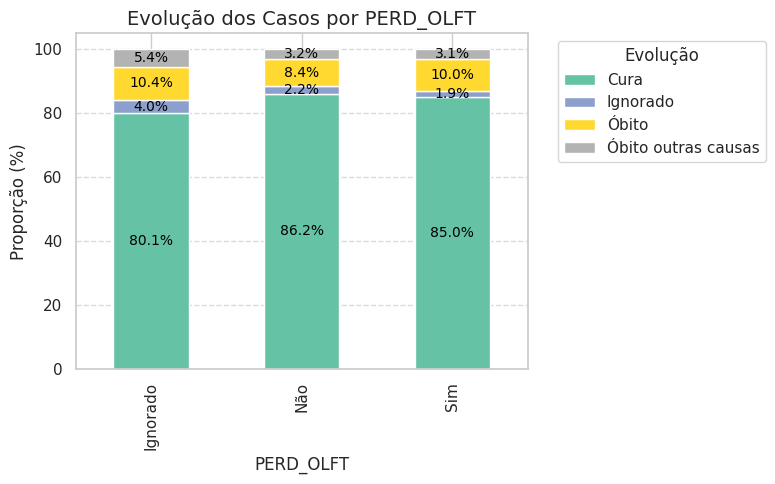

➡️ Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa

📌 PERD_PALA


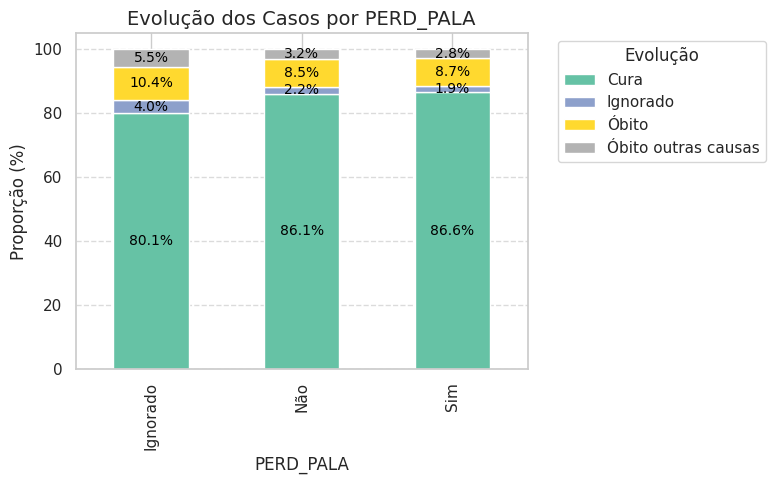

➡️ Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa

📌 OUTRO_SIN


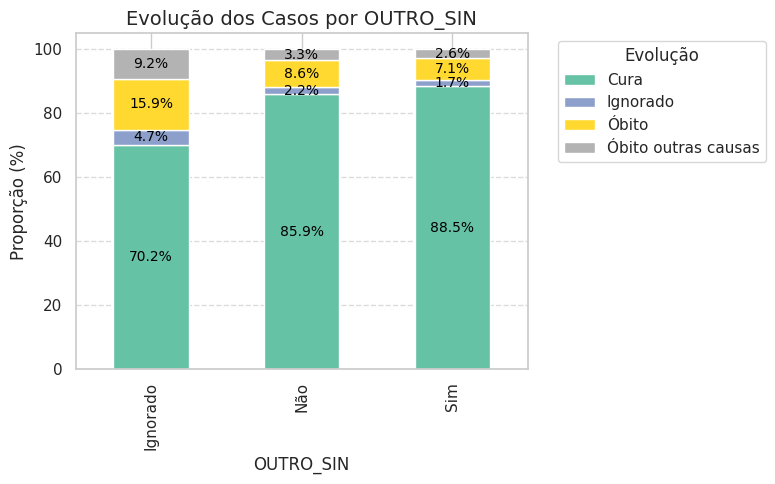

➡️ Teste Qui-Quadrado: p = 0.0000 ✅ Associação significativa


In [110]:
df = pd.read_csv("/content/drive/MyDrive/TCC I/Analise de Dados/INFLUD24-03-02-2025.csv", sep=";", encoding="latin1", low_memory=False)
df_test = df

# Mapeamentos
df_test['EVOLUCAO'] = df_test['EVOLUCAO'].map({1: 'Cura', 2: 'Óbito', 3: 'Óbito outras causas', 9: 'Ignorado'})
mapa_binario = {1: 'Sim', 2: 'Não', 9: 'Ignorado'}

# Listas completas
fatores_binarios = [
    'PUERPERA', 'CARDIOPATI', 'HEMATOLOGI', 'SIND_DOWN', 'HEPATICA',
    'ASMA', 'DIABETES', 'NEUROLOGIC', 'PNEUMOPATI', 'IMUNODEPRE',
    'RENAL', 'OBESIDADE', 'OUT_MORBI'
]
sintomas = [
    'FEBRE', 'TOSSE', 'GARGANTA', 'DISPNEIA', 'DESC_RESP', 'SATURACAO',
    'DIARREIA', 'VOMITO', 'DOR_ABD', 'FADIGA', 'PERD_OLFT', 'PERD_PALA', 'OUTRO_SIN'
]

# Mapeando os dados binários
for col in fatores_binarios + sintomas:
    if col in df_test.columns:
        df_test[col] = df_test[col].map(mapa_binario)

# Função para plotar e fazer teste qui-quadrado
def plot_crosstab_annotated(col, evol='EVOLUCAO'):
    if col not in df_test.columns:
        return

    temp_df_test = df_test[[col, evol]].dropna()
    if temp_df_test.empty or temp_df_test[col].nunique() < 1:
        print(f'⚠️ Coluna {col} não possui dados suficientes para plotar.')
        return

    crosstab = pd.crosstab(temp_df_test[col], temp_df_test[evol], normalize='index') * 100
    counts = pd.crosstab(temp_df_test[col], temp_df_test[evol])

    ax = crosstab.plot(kind='bar', stacked=True, colormap='Set2', figsize=(8, 5))
    plt.title(f'Evolução dos Casos por {col}', fontsize=14)
    plt.ylabel('Proporção (%)')
    plt.xlabel(col)
    plt.legend(title='Evolução', bbox_to_anchor=(1.05, 1), loc='upper left')

    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height:.1f}%', (p.get_x() + p.get_width() / 2, p.get_y() + height / 2),
                        ha='center', va='center', fontsize=10, color='black')

    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    chi2, p, _, _ = chi2_contingency(counts)
    print(f'➡️ Teste Qui-Quadrado: p = {p:.4f} {"✅ Associação significativa" if p < 0.05 else "❌ Sem associação significativa"}')

# Geração dos gráficos para colunas válidas
colunas_validas = [col for col in fatores_binarios + sintomas if col in df_test.columns]
for col in colunas_validas:
    print(f'\n📌 {col}')
    plot_crosstab_annotated(col)



In [70]:
for col in fatores_binarios:
    if col in df.columns:
        print(f'{col}:', df[col].unique())


PUERPERA: [nan 'Não' 'Ignorado' 'Sim']
CARDIOPATI: [nan 'Não' 'Sim' 'Ignorado']
HEMATOLOGI: [nan 'Não' 'Sim' 'Ignorado']
SIND_DOWN: [nan 'Não' 'Sim' 'Ignorado']
HEPATICA: [nan 'Não' 'Sim' 'Ignorado']
ASMA: [nan 'Sim' 'Não' 'Ignorado']
DIABETES: [nan 'Sim' 'Não' 'Ignorado']
NEUROLOGIC: [nan 'Não' 'Sim' 'Ignorado']
PNEUMOPATI: [nan 'Sim' 'Não' 'Ignorado']
IMUNODEPRE: [nan 'Não' 'Sim' 'Ignorado']
RENAL: [nan 'Não' 'Sim' 'Ignorado']
OBESIDADE: [nan 'Não' 'Sim' 'Ignorado']
OUT_MORBI: [nan 'Ignorado' 'Sim' 'Não']


# Análise Clínica e Epidemiológica
## Sintomas vs Desfecho (EVOLUCAO)


📌 Sintoma: FEBRE


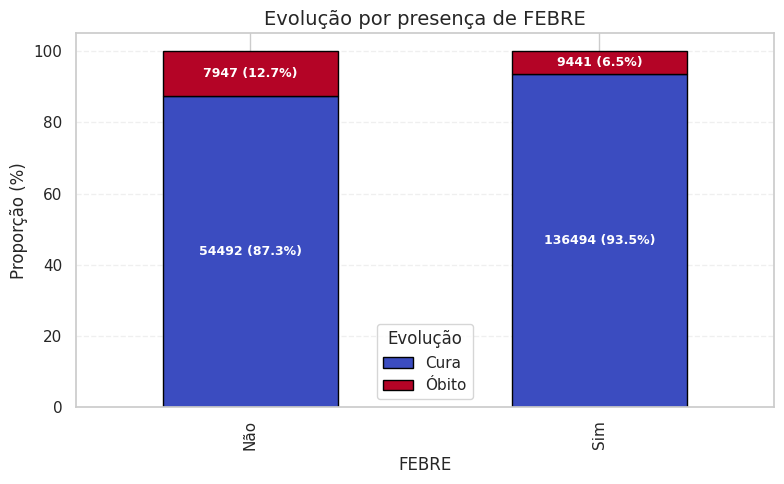

➡️ Teste Qui-Quadrado para FEBRE: p = 0.0000 ✅ Associação significativa

📌 Sintoma: TOSSE


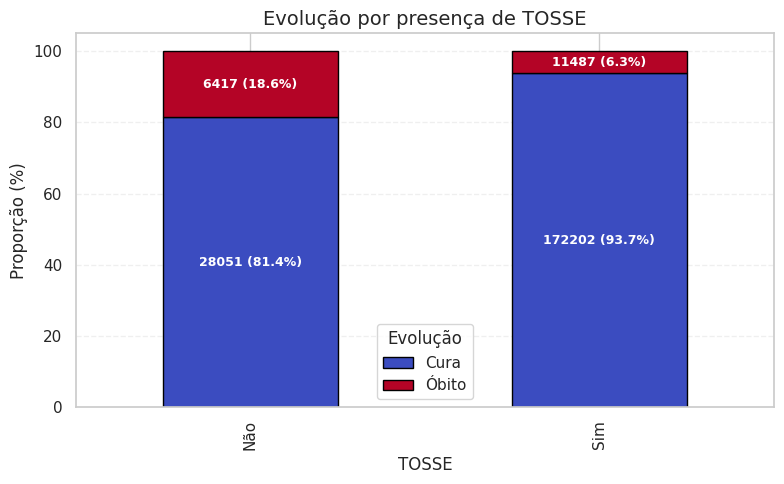

➡️ Teste Qui-Quadrado para TOSSE: p = 0.0000 ✅ Associação significativa

📌 Sintoma: GARGANTA


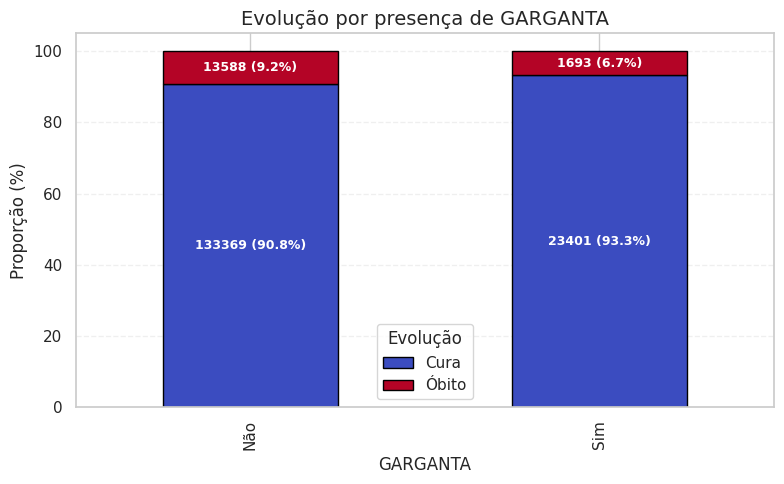

➡️ Teste Qui-Quadrado para GARGANTA: p = 0.0000 ✅ Associação significativa

📌 Sintoma: DISPNEIA


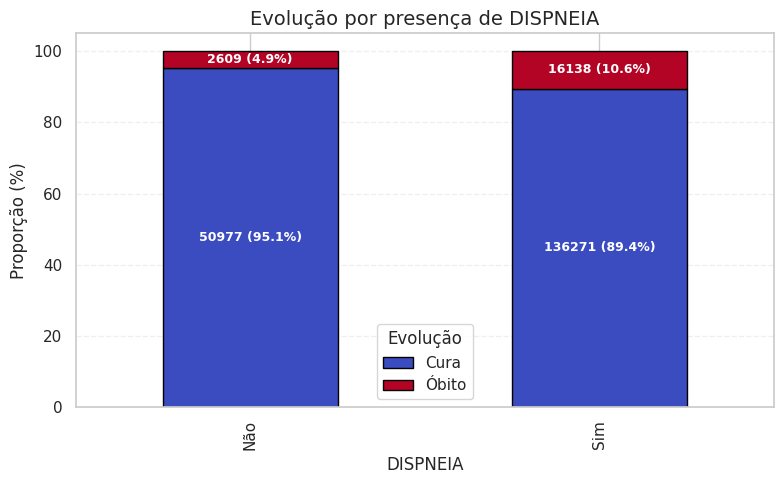

➡️ Teste Qui-Quadrado para DISPNEIA: p = 0.0000 ✅ Associação significativa

📌 Sintoma: DESC_RESP


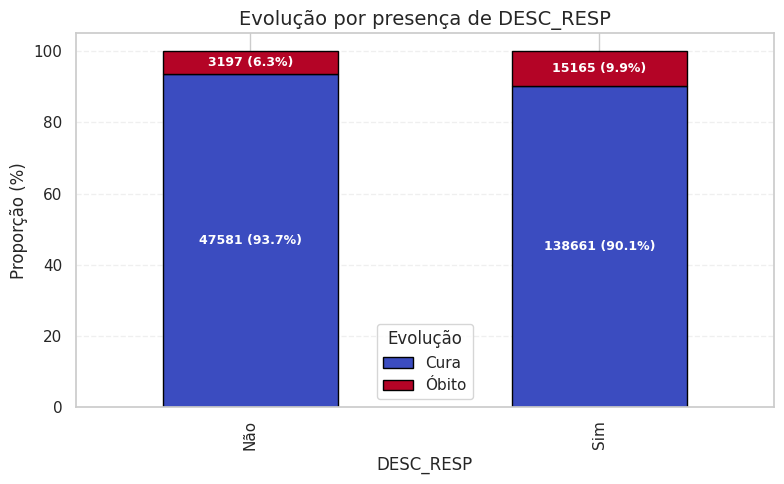

➡️ Teste Qui-Quadrado para DESC_RESP: p = 0.0000 ✅ Associação significativa

📌 Sintoma: SATURACAO


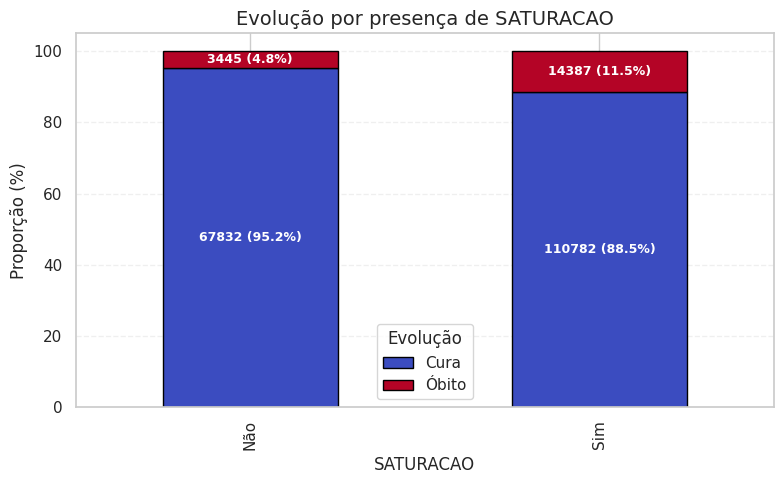

➡️ Teste Qui-Quadrado para SATURACAO: p = 0.0000 ✅ Associação significativa

📌 Sintoma: DIARREIA


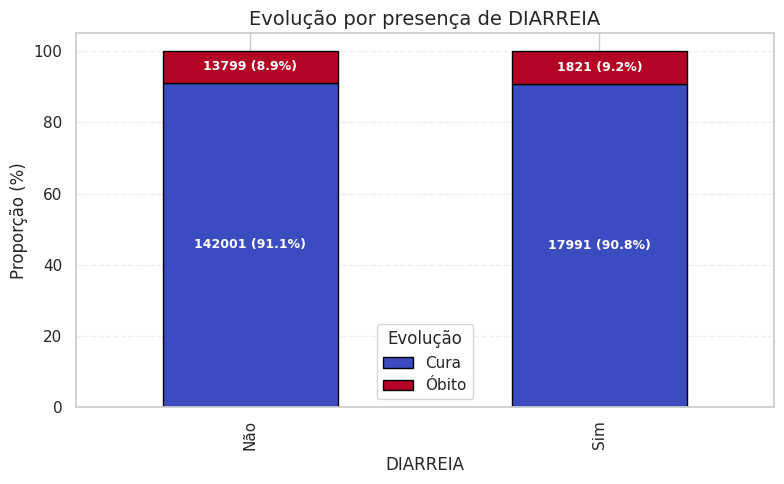

➡️ Teste Qui-Quadrado para DIARREIA: p = 0.1224 ❌ Sem associação significativa

📌 Sintoma: VOMITO


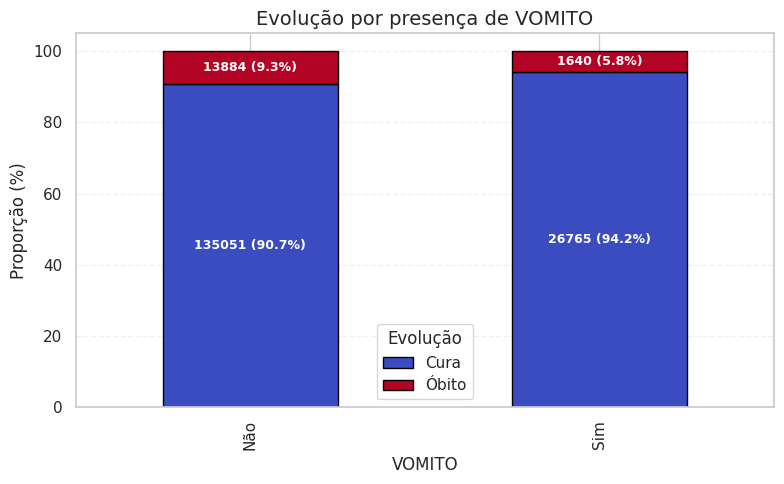

➡️ Teste Qui-Quadrado para VOMITO: p = 0.0000 ✅ Associação significativa

📌 Sintoma: DOR_ABD


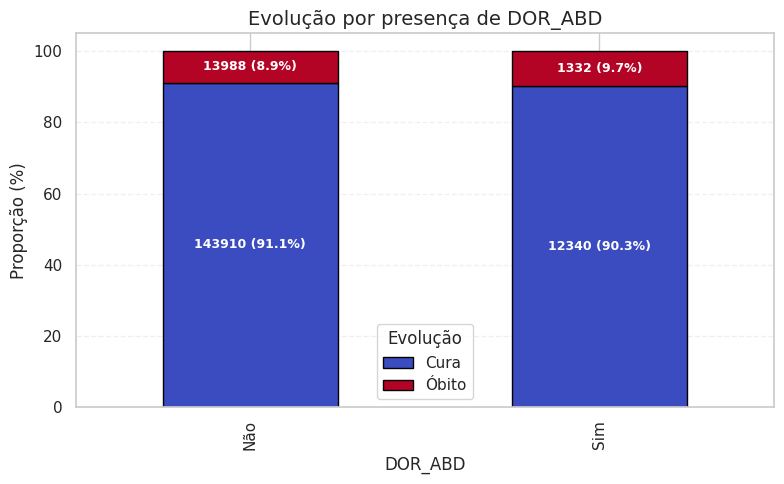

➡️ Teste Qui-Quadrado para DOR_ABD: p = 0.0005 ✅ Associação significativa

📌 Sintoma: FADIGA


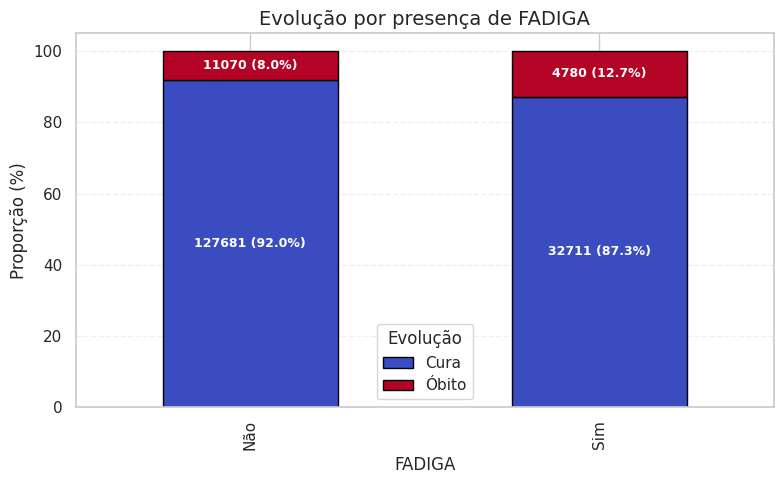

➡️ Teste Qui-Quadrado para FADIGA: p = 0.0000 ✅ Associação significativa

📌 Sintoma: PERD_OLFT


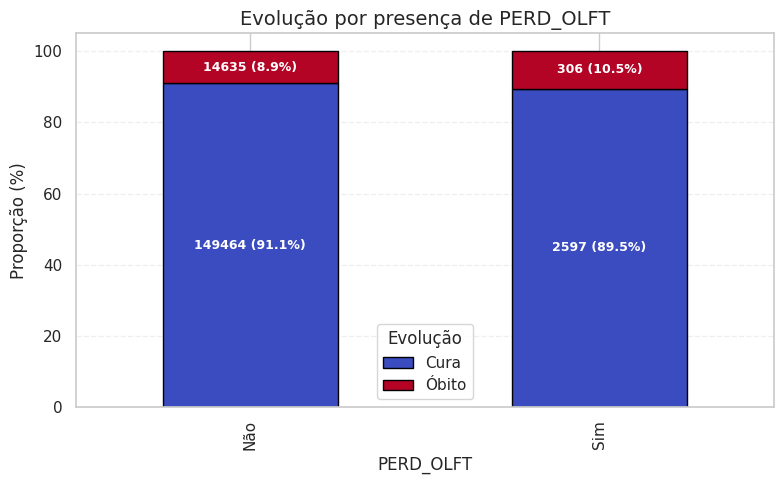

➡️ Teste Qui-Quadrado para PERD_OLFT: p = 0.0027 ✅ Associação significativa

📌 Sintoma: PERD_PALA


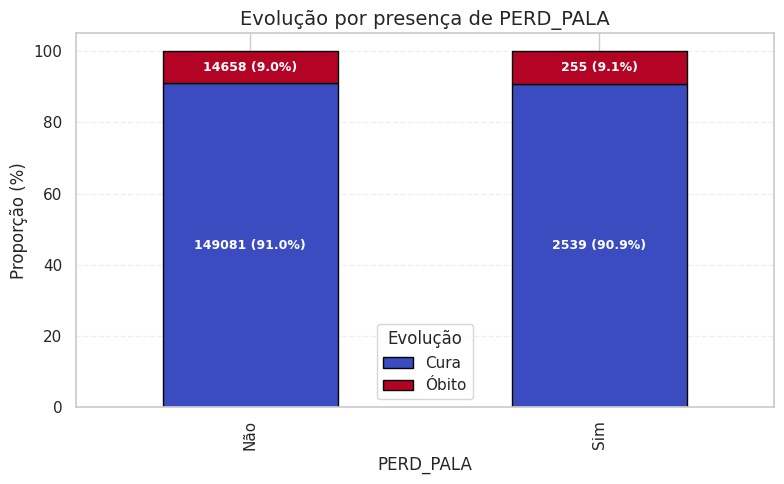

➡️ Teste Qui-Quadrado para PERD_PALA: p = 0.7740 ❌ Sem associação significativa

📌 Sintoma: OUTRO_SIN


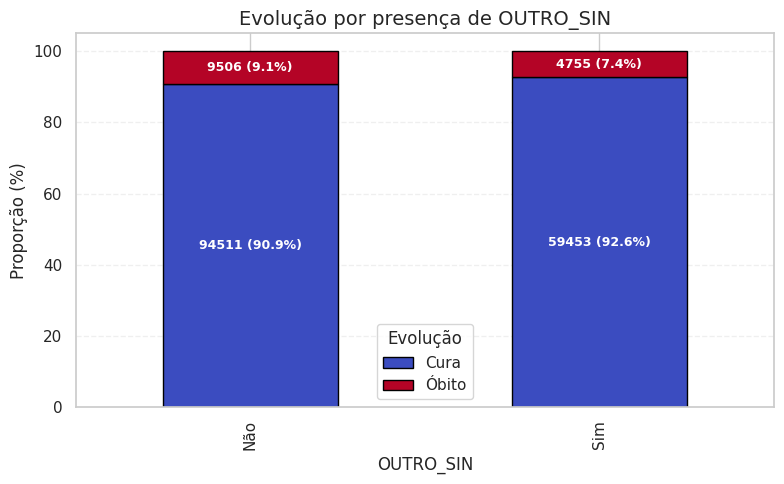

➡️ Teste Qui-Quadrado para OUTRO_SIN: p = 0.0000 ✅ Associação significativa


In [107]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
df = pd.read_csv("/content/drive/MyDrive/TCC I/Analise de Dados/INFLUD24-03-02-2025.csv", sep=";", encoding="latin1", low_memory=False)

# 🧼 1. Mapeamento das variáveis binárias
mapa_binario = {1: 'Sim', 2: 'Não', 9: 'Ignorado'}

# Lista de sintomas
sintomas = ['FEBRE', 'TOSSE', 'GARGANTA', 'DISPNEIA', 'DESC_RESP', 'SATURACAO',
            'DIARREIA', 'VOMITO', 'DOR_ABD', 'FADIGA', 'PERD_OLFT', 'PERD_PALA', 'OUTRO_SIN']

# Mapeando sintomas e evolução
for col in sintomas:
    if col in df.columns:
        df[col] = df[col].replace(mapa_binario)

if 'EVOLUCAO' in df.columns:
    df['EVOLUCAO'] = df['EVOLUCAO'].map({
        1: 'Cura',
        2: 'Óbito',
        3: 'Óbito outras causas',
        9: 'Ignorado'
    })

# 📊 2. Função de visualização
def plot_crosstab(col, evol='EVOLUCAO'):
    if col not in df.columns:
        print(f"❌ Coluna {col} não encontrada.")
        return

    # Filtrar dados válidos
    df_filtrado = df[df[col].isin(['Sim', 'Não']) & df[evol].isin(['Cura', 'Óbito'])]

    if df_filtrado[col].nunique() < 2:
        print(f"⚠️ Coluna {col} não possui dados suficientes.")
        return

    # Tabelas de proporções e absolutas
    crosstab_pct = pd.crosstab(df_filtrado[col], df_filtrado[evol], normalize='index') * 100
    crosstab_abs = pd.crosstab(df_filtrado[col], df_filtrado[evol])

    # Plot
    ax = crosstab_pct.plot(kind='bar', stacked=True, colormap='coolwarm', figsize=(8, 5), edgecolor='black')

    # Adiciona números absolutos e porcentagens
    for i, (idx, row) in enumerate(crosstab_pct.iterrows()):
        y_offset = 0
        for j, evol_type in enumerate(crosstab_pct.columns):
            height = row[evol_type]
            abs_value = crosstab_abs.loc[idx, evol_type]
            if height > 3:
                ax.text(i, y_offset + height / 2, f'{abs_value} ({height:.1f}%)',
                        ha='center', va='center', fontsize=9, color='white', weight='bold')
            y_offset += height

    plt.title(f'Evolução por presença de {col}', fontsize=14)
    plt.ylabel('Proporção (%)')
    plt.xlabel(col)
    plt.legend(title='Evolução')
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.show()

    # 🔬 Teste Qui-Quadrado
    chi2, p, dof, expected = chi2_contingency(crosstab_abs)
    print(f'➡️ Teste Qui-Quadrado para {col}: p = {p:.4f} {"✅ Associação significativa" if p < 0.05 else "❌ Sem associação significativa"}')

# 🔁 3. Executar para todos os sintomas
for col in sintomas:
    print(f'\n📌 Sintoma: {col}')
    plot_crosstab(col)


## Fatores de risco vs Desfecho (EVOLUCAO)


📌 Fator de Risco: PUERPERA


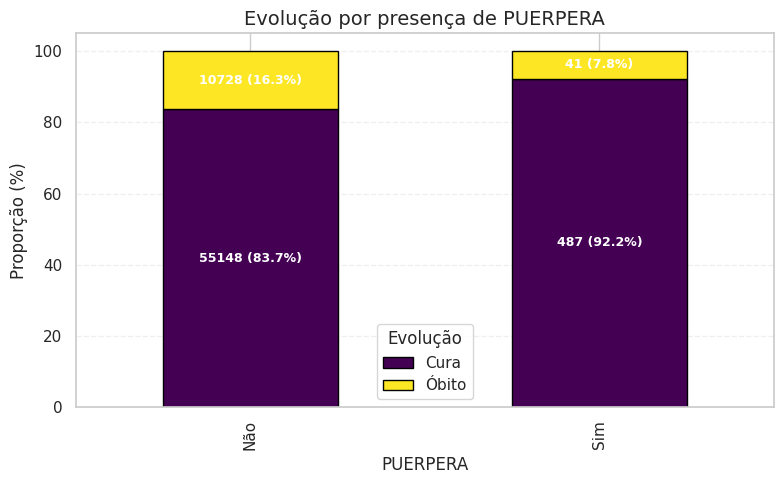

➡️ Teste Qui-Quadrado para PUERPERA: p = 0.0000 ✅ Associação significativa

📌 Fator de Risco: CARDIOPATI


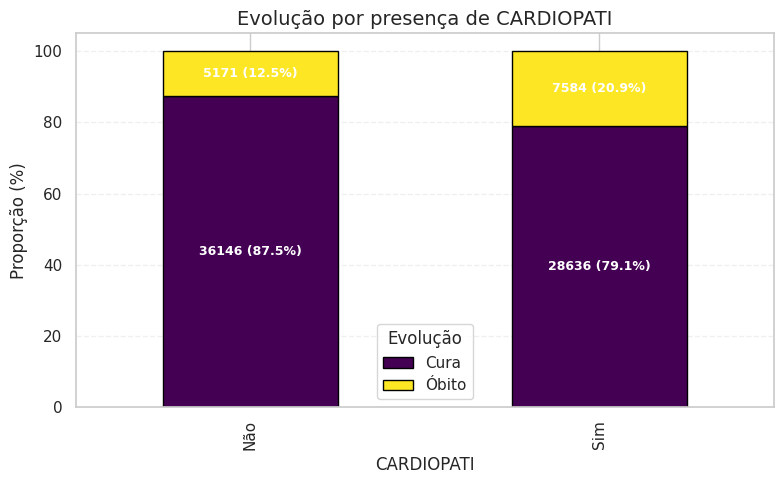

➡️ Teste Qui-Quadrado para CARDIOPATI: p = 0.0000 ✅ Associação significativa

📌 Fator de Risco: HEMATOLOGI


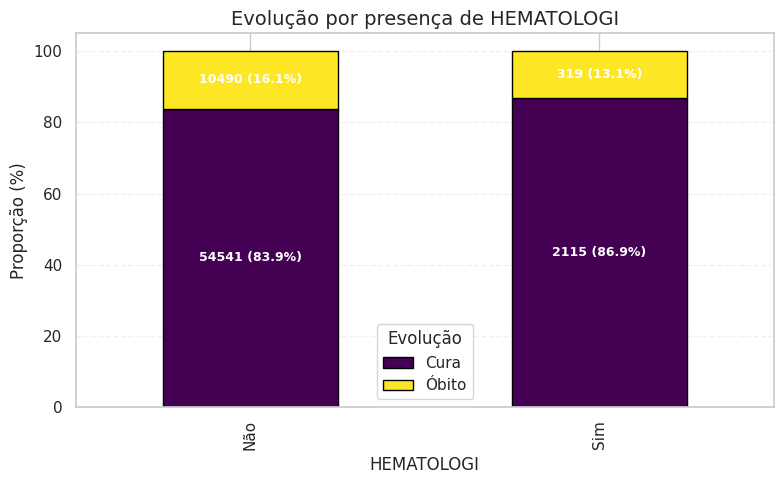

➡️ Teste Qui-Quadrado para HEMATOLOGI: p = 0.0001 ✅ Associação significativa

📌 Fator de Risco: SIND_DOWN


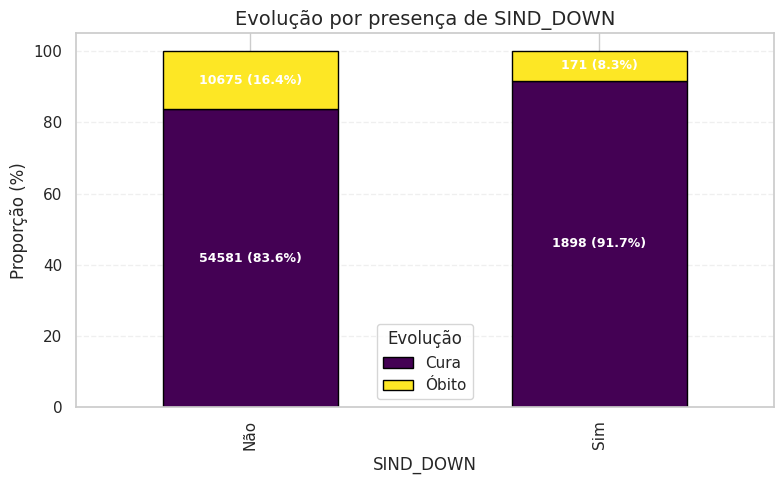

➡️ Teste Qui-Quadrado para SIND_DOWN: p = 0.0000 ✅ Associação significativa

📌 Fator de Risco: HEPATICA


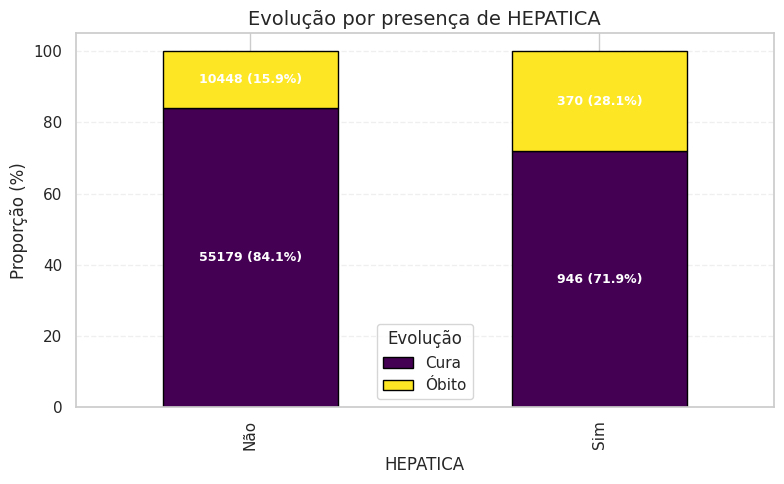

➡️ Teste Qui-Quadrado para HEPATICA: p = 0.0000 ✅ Associação significativa

📌 Fator de Risco: ASMA


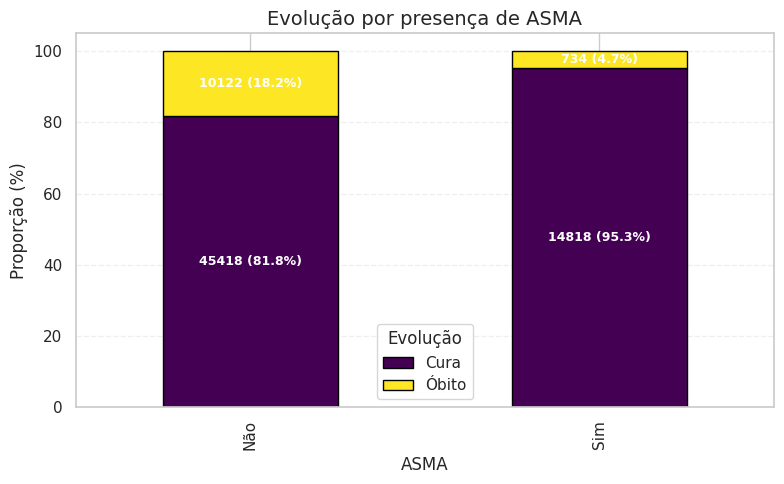

➡️ Teste Qui-Quadrado para ASMA: p = 0.0000 ✅ Associação significativa

📌 Fator de Risco: DIABETES


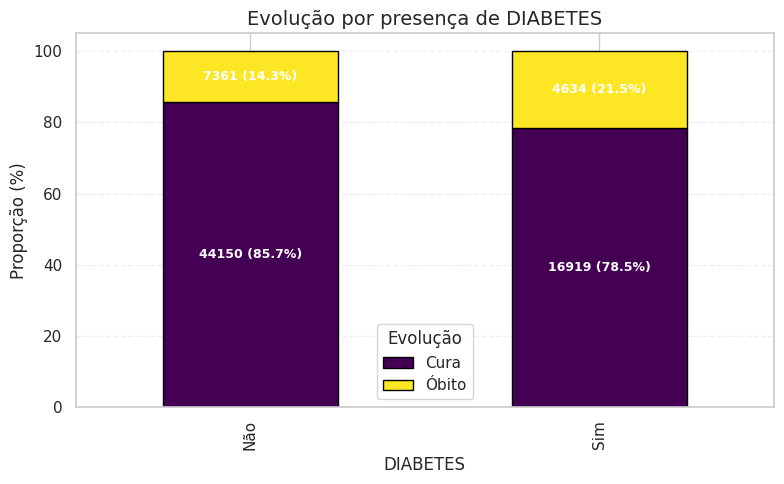

➡️ Teste Qui-Quadrado para DIABETES: p = 0.0000 ✅ Associação significativa

📌 Fator de Risco: NEUROLOGIC


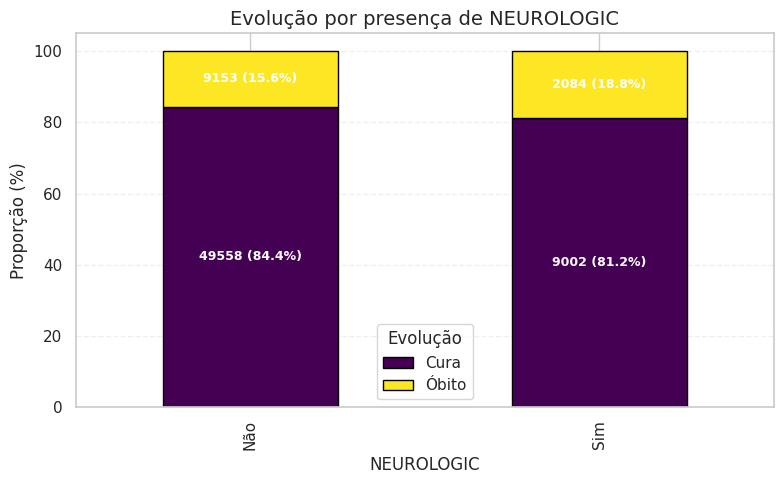

➡️ Teste Qui-Quadrado para NEUROLOGIC: p = 0.0000 ✅ Associação significativa

📌 Fator de Risco: PNEUMOPATI


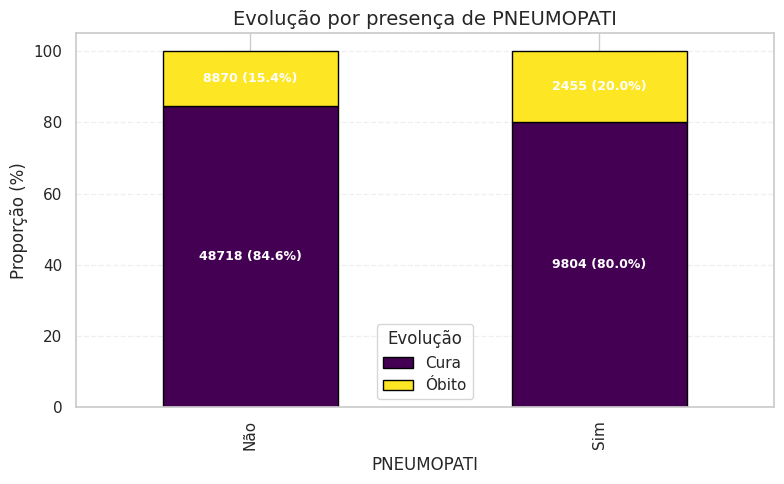

➡️ Teste Qui-Quadrado para PNEUMOPATI: p = 0.0000 ✅ Associação significativa

📌 Fator de Risco: IMUNODEPRE


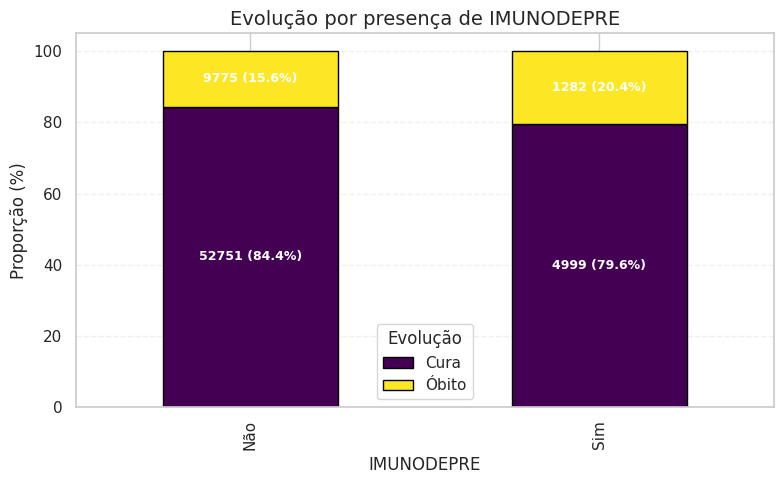

➡️ Teste Qui-Quadrado para IMUNODEPRE: p = 0.0000 ✅ Associação significativa

📌 Fator de Risco: RENAL


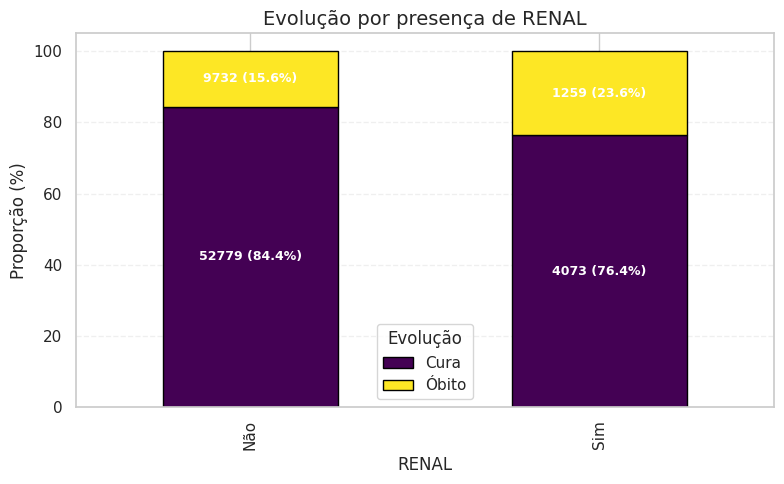

➡️ Teste Qui-Quadrado para RENAL: p = 0.0000 ✅ Associação significativa

📌 Fator de Risco: OBESIDADE


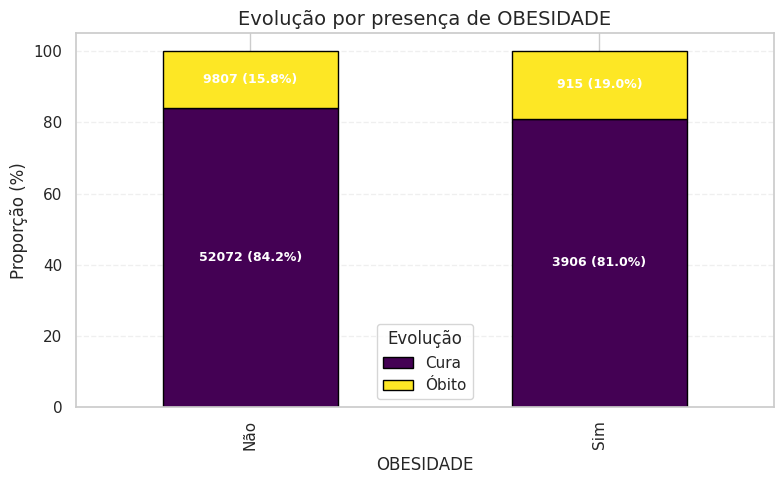

➡️ Teste Qui-Quadrado para OBESIDADE: p = 0.0000 ✅ Associação significativa

📌 Fator de Risco: OUT_MORBI


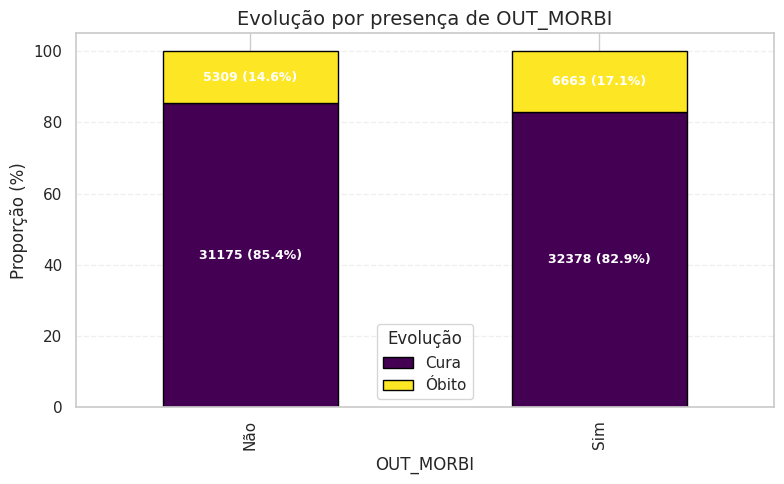

➡️ Teste Qui-Quadrado para OUT_MORBI: p = 0.0000 ✅ Associação significativa


In [112]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# 📥 Leitura do dataset
df = pd.read_csv("/content/drive/MyDrive/TCC I/Analise de Dados/INFLUD24-03-02-2025.csv",
                 sep=";", encoding="latin1", low_memory=False)

# 🧼 Mapeamento binário
mapa_binario = {1: 'Sim', 2: 'Não', 9: 'Ignorado'}

# Fatores de risco
fatores_risco = ['PUERPERA', 'CARDIOPATI', 'HEMATOLOGI', 'SIND_DOWN', 'HEPATICA',
                 'ASMA', 'DIABETES', 'NEUROLOGIC', 'PNEUMOPATI', 'IMUNODEPRE',
                 'RENAL', 'OBESIDADE', 'OUT_MORBI']

# Aplicar mapeamento às colunas binárias
for col in fatores_risco:
    if col in df.columns:
        df[col] = df[col].replace(mapa_binario)

# Mapear evolução
if 'EVOLUCAO' in df.columns:
    df['EVOLUCAO'] = df['EVOLUCAO'].map({
        1: 'Cura',
        2: 'Óbito',
        3: 'Óbito outras causas',
        9: 'Ignorado'
    })

# 📊 Função para análise e visualização
def plot_crosstab(col, evol='EVOLUCAO'):
    if col not in df.columns:
        print(f"❌ Coluna {col} não encontrada.")
        return

    df_filtrado = df[df[col].isin(['Sim', 'Não']) & df[evol].isin(['Cura', 'Óbito'])]

    if df_filtrado[col].nunique() < 2:
        print(f"⚠️ Coluna {col} não possui dados suficientes.")
        return

    crosstab_pct = pd.crosstab(df_filtrado[col], df_filtrado[evol], normalize='index') * 100
    crosstab_abs = pd.crosstab(df_filtrado[col], df_filtrado[evol])

    ax = crosstab_pct.plot(kind='bar', stacked=True, colormap='viridis', figsize=(8, 5), edgecolor='black')

    # Anotar gráfico com contagem e porcentagem
    for i, (idx, row) in enumerate(crosstab_pct.iterrows()):
        y_offset = 0
        for j, evol_type in enumerate(crosstab_pct.columns):
            height = row[evol_type]
            abs_value = crosstab_abs.loc[idx, evol_type]
            if height > 3:
                ax.text(i, y_offset + height / 2, f'{abs_value} ({height:.1f}%)',
                        ha='center', va='center', fontsize=9, color='white', weight='bold')
            y_offset += height

    plt.title(f'Evolução por presença de {col}', fontsize=14)
    plt.ylabel('Proporção (%)')
    plt.xlabel(col)
    plt.legend(title='Evolução')
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 🔬 Teste Qui-Quadrado
    chi2, p, _, _ = chi2_contingency(crosstab_abs)
    print(f'➡️ Teste Qui-Quadrado para {col}: p = {p:.4f} {"✅ Associação significativa" if p < 0.05 else "❌ Sem associação significativa"}')

# 🚀 Executar para todos os fatores de risco
for col in fatores_risco:
    print(f'\n📌 Fator de Risco: {col}')
    plot_crosstab(col)


## Quantidade de fatores/sintomas por paciente vs Evolução

<ipython-input-78-63dcaacdcf4d>:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df[colunas].applymap(lambda x: 1 if x == 'Sim' else 0)
<ipython-input-78-63dcaacdcf4d>:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df[colunas].applymap(lambda x: 1 if x == 'Sim' else 0)
<ipython-input-78-63dcaacdcf4d>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['EVOLUCAO'].isin(['Cura', 'Óbito'])], x='EVOLUCAO', y='N_SINTOMAS', palette='Blues')
<ipython-input-78-63dcaacdcf4d>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['EVOLUCAO'].isin(['Cura', 'Óbito'])], x='EVOLUCAO', y='N_FATORES'

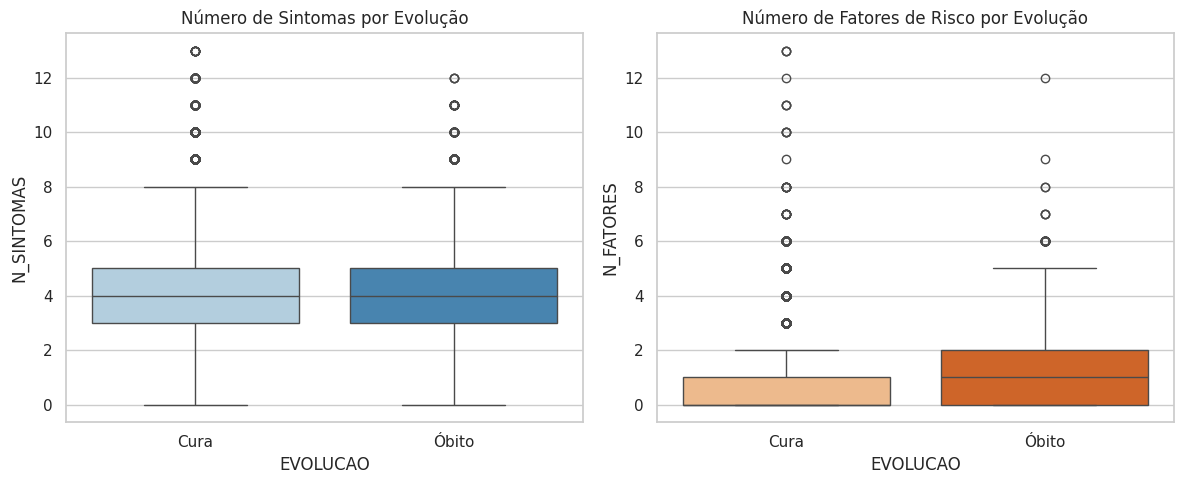

In [78]:
# Codifica "Sim" como 1, "Não/Ignorado" como 0 para contar
def codifica_binario(colunas):
    return df[colunas].applymap(lambda x: 1 if x == 'Sim' else 0)

# Total de sintomas e fatores
df['N_SINTOMAS'] = codifica_binario(sintomas).sum(axis=1)
df['N_FATORES'] = codifica_binario(fatores_risco).sum(axis=1)

# Gráfico de dispersão (boxplot)
plt.figure(figsize=(12,5))

# Sintomas
plt.subplot(1, 2, 1)
sns.boxplot(data=df[df['EVOLUCAO'].isin(['Cura', 'Óbito'])], x='EVOLUCAO', y='N_SINTOMAS', palette='Blues')
plt.title('Número de Sintomas por Evolução')

# Fatores
plt.subplot(1, 2, 2)
sns.boxplot(data=df[df['EVOLUCAO'].isin(['Cura', 'Óbito'])], x='EVOLUCAO', y='N_FATORES', palette='Oranges')
plt.title('Número de Fatores de Risco por Evolução')

plt.tight_layout()
plt.show()


# Evolução vs UTI vs HOSPITAL
HOSPITAL:O paciente foi internado?
Onde:
1-Sim
2-Não
9-Ignorado

DT_INTERNA: Data em que o paciente foi hospitalizado.

UTI: O paciente foi internado em UTI?
1-Sim
2-Não
9-Ignorado

DT_ENTUTI:Data de entrada do paciente na unidade de Terapia intensiva (UTI).
DT_SAIDUTI: Data em que o paciente saiu da unidade de Terapia intensiva (UTI)

SUPORT_VEN: O paciente fez uso de suporte ventilatório?  
Onde,
1-Sim, invasivo
2-Sim, não invasivo
3-Não
9-Ignorado

In [89]:
df = pd.read_csv("/content/drive/MyDrive/TCC I/Analise de Dados/INFLUD24-03-02-2025.csv", sep=";", encoding="latin1", low_memory=False)
# Mapeamento das variáveis binárias
mapa_binario = {1: 'Sim', 2: 'Não', 9: 'Ignorado'}

df['HOSPITAL'] = df['HOSPITAL'].map(mapa_binario)
df['UTI'] = df['UTI'].map(mapa_binario)
# Se tiver uma coluna de ventilação mecânica:
# df['SUPORT_VEN'] = df['SUPORT_VEN'].map(mapa_binario)
df['SUPORT_VEN'] = df['SUPORT_VEN'].map({1: 'Sim, invasivo', 2: 'Sim, não invasivo', 3: 'Não', 9: 'Ignorado'})

# Mapear EVOLUCAO se ainda não foi feito
df['EVOLUCAO'] = df['EVOLUCAO'].map({1: 'Cura', 2: 'Óbito', 3: 'Óbito outras causas', 9: 'Ignorado'})


In [90]:
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

def plot_evolucao_recurso(col):
    df_valid = df[df[col].isin(['Sim', 'Não']) & df['EVOLUCAO'].isin(['Cura', 'Óbito'])]
    if df_valid.empty:
        print(f"⚠️ Coluna {col} sem dados válidos.")
        return

    crosstab_pct = pd.crosstab(df_valid[col], df_valid['EVOLUCAO'], normalize='index') * 100
    crosstab_abs = pd.crosstab(df_valid[col], df_valid['EVOLUCAO'])

    ax = crosstab_pct.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='coolwarm', edgecolor='black')
    for i, row in enumerate(crosstab_pct.values):
        cumulative = 0
        for j, pct in enumerate(row):
            count = crosstab_abs.iloc[i, j]
            if pct > 3:
                ax.text(i, cumulative + pct / 2, f'{int(count)}', ha='center', va='center', fontsize=9, color='white')
            cumulative += pct

    plt.title(f'Evolução por uso de {col}', fontsize=14)
    plt.ylabel('Proporção (%)')
    plt.xlabel(col)
    plt.legend(title='Evolução')
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Teste Qui-quadrado
    chi2, p, _, _ = chi2_contingency(crosstab_abs)
    print(f'📊 Teste Qui-Quadrado: p = {p:.4f} → {"✅ Associação significativa" if p < 0.05 else "❌ Sem associação significativa"}')



📌 Analisando: HOSPITAL


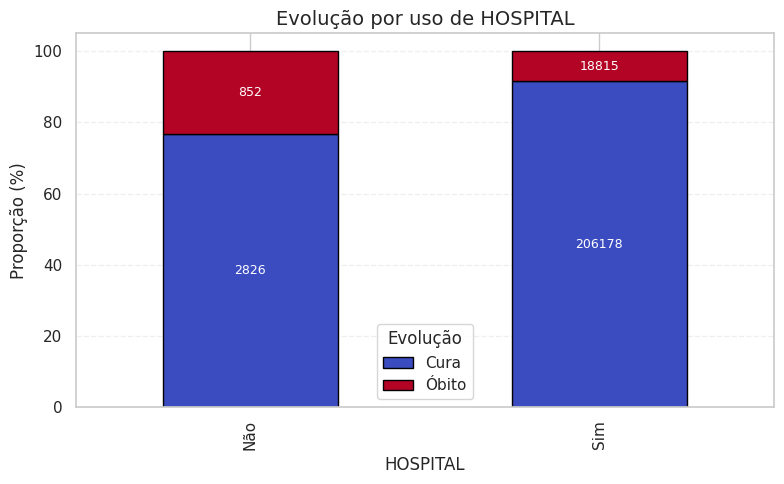

📊 Teste Qui-Quadrado: p = 0.0000 → ✅ Associação significativa

📌 Analisando: UTI


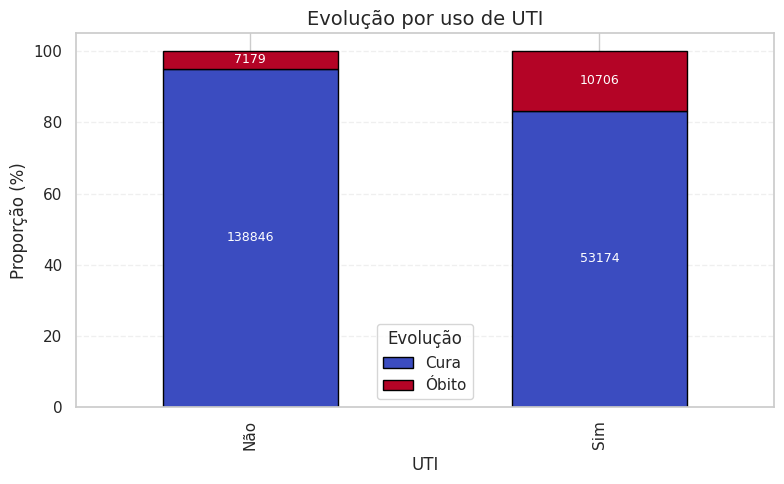

📊 Teste Qui-Quadrado: p = 0.0000 → ✅ Associação significativa


In [91]:
for var in ['HOSPITAL', 'UTI']:  # Adicione 'SUPORT_VEN' se existir
    print(f'\n📌 Analisando: {var}')
    plot_evolucao_recurso(var)


In [92]:
# Converter datas
df['DT_INTERNA'] = pd.to_datetime(df['DT_INTERNA'], errors='coerce')
df['DT_ENTUTI'] = pd.to_datetime(df['DT_ENTUTI'], errors='coerce')
df['DT_SAIDUTI'] = pd.to_datetime(df['DT_SAIDUTI'], errors='coerce')

# Criar variável de duração da UTI
df['DUR_UTI'] = (df['DT_SAIDUTI'] - df['DT_ENTUTI']).dt.days


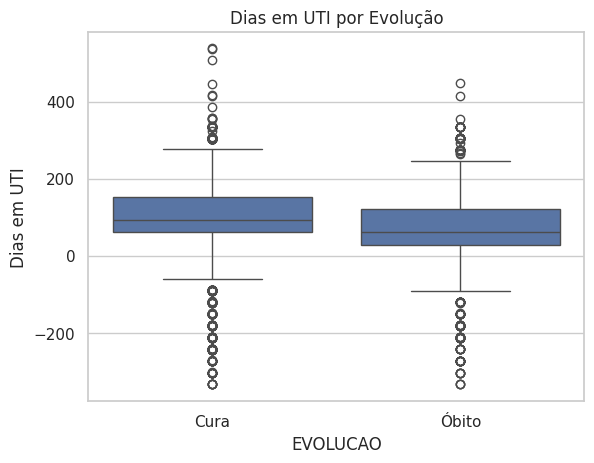

In [93]:
# Boxplot de dias na UTI por evolução
sns.boxplot(data=df[df['EVOLUCAO'].isin(['Cura', 'Óbito'])], x='EVOLUCAO', y='DUR_UTI')
plt.title('Dias em UTI por Evolução')
plt.ylabel('Dias em UTI')
plt.show()


# Analise Preditiva

In [117]:
# 🔧 1. Bibliotecas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

# 🔽 2. Suponha que df já está carregado
# Exemplo: df = pd.read_csv('srag.csv')
df = pd.read_csv("/content/drive/MyDrive/TCC I/Analise de Dados/INFLUD24-03-02-2025.csv", sep=";", encoding="latin1", low_memory=False)


In [118]:
# 🔄 3. Mapeamento da coluna EVOLUCAO para binária
df = df.copy()
df = df[df['EVOLUCAO'].isin([1, 2])]  # 1=Cura, 2=Óbito
df['EVOLUCAO_BIN'] = df['EVOLUCAO'].map({1: 0, 2: 1})  # 0=Cura, 1=Óbito

# 🎯 4. Definir variáveis explicativas (fatores + sintomas)
fatores = [
    'PUERPERA', 'CARDIOPATI', 'HEMATOLOGI', 'SIND_DOWN', 'HEPATICA',
    'ASMA', 'DIABETES', 'NEUROLOGIC', 'PNEUMOPATI', 'IMUNODEPRE',
    'RENAL', 'OBESIDADE', 'OUT_MORBI'
]

sintomas = [
    'FEBRE', 'TOSSE', 'GARGANTA', 'DISPNEIA', 'DESC_RESP', 'SATURACAO',
    'DIARREIA', 'VOMITO', 'DOR_ABD', 'FADIGA', 'PERD_OLFT', 'PERD_PALA',
    'OUTRO_SIN'
]

features = fatores + sintomas

# 🧼 5. Limpeza: manter somente os válidos (1=Sim, 2=Não)
df_model = df[df[features].applymap(lambda x: x in [1, 2]).all(axis=1)]

# 📦 6. Transformar 1/2 em 0/1
X = df_model[features].applymap(lambda x: 1 if x == 1 else 0)
y = df_model['EVOLUCAO_BIN']

# 🎲 7. Treinar/Testar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 🌲 8. Modelo
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# ✅ 9. Avaliação
y_pred = rf.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

<ipython-input-118-bf31eaf22564>:22: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_model = df[df[features].applymap(lambda x: x in [1, 2]).all(axis=1)]
<ipython-input-118-bf31eaf22564>:25: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X = df_model[features].applymap(lambda x: 1 if x == 1 else 0)


Accuracy: 0.8264822516684399
              precision    recall  f1-score   support

           0       0.85      0.96      0.90      8751
           1       0.29      0.09      0.13      1588

    accuracy                           0.83     10339
   macro avg       0.57      0.52      0.52     10339
weighted avg       0.77      0.83      0.79     10339



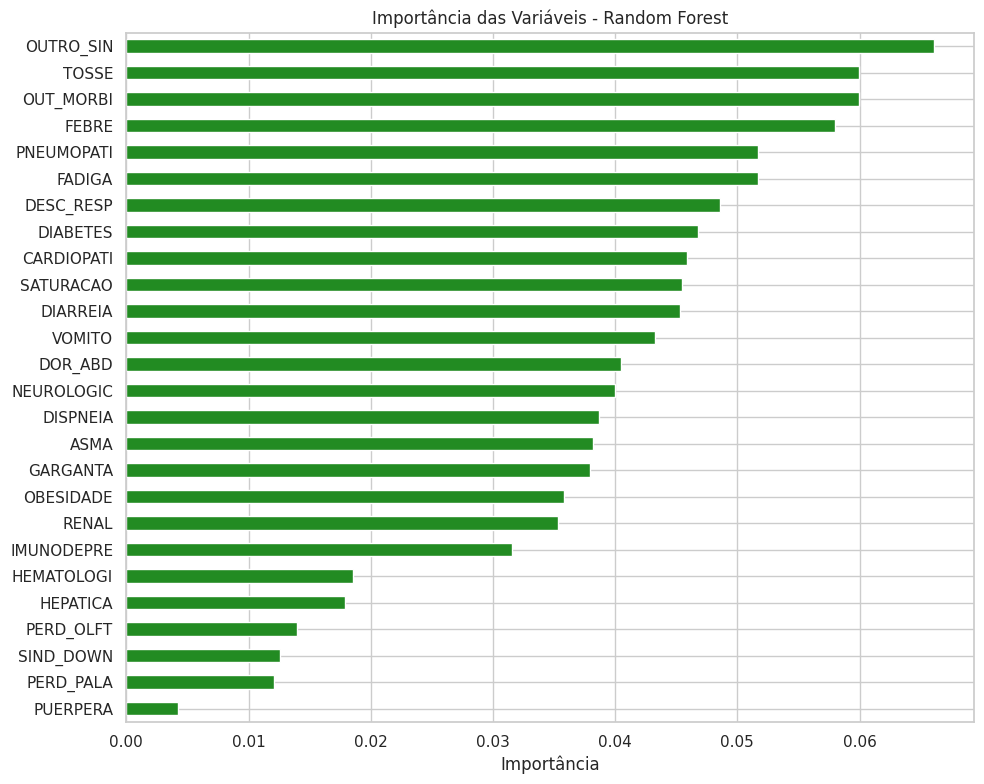

In [119]:
# 📊 10. Importância das Variáveis
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 8))
importances.plot(kind='barh', color='forestgreen')
plt.title('Importância das Variáveis - Random Forest')
plt.xlabel('Importância')
plt.tight_layout()
plt.show()

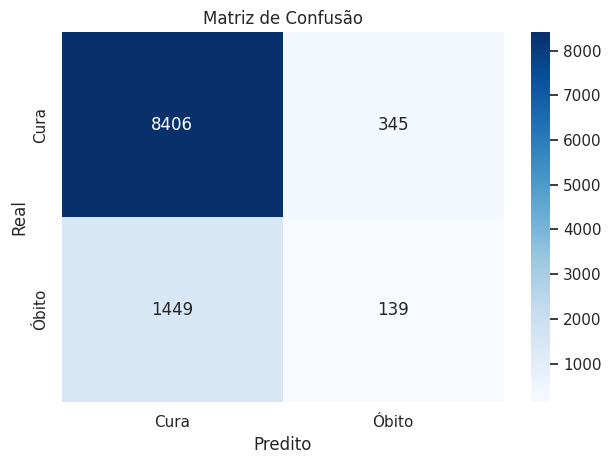

In [120]:
# 🔍 11. Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Cura','Óbito'], yticklabels=['Cura','Óbito'])
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.tight_layout()
plt.show()

### Resultados
sse resultado mostra um problema comum em bases de dados desbalanceadas: o modelo tem alta acurácia geral, mas péssima performance para a classe minoritária — neste caso, os óbitos.

Vamos interpretar e depois propor soluções.

📌 Interpretação dos Resultados

Classe 0 (Cura):

Precision: 0.85 → dos casos que o modelo previu como “Cura”, 85% estavam corretos.

Recall: 0.96 → o modelo identificou corretamente 96% dos pacientes que realmente tiveram cura.

Classe 1 (Óbito):

Precision: 0.29 → apenas 29% das previsões de óbito estavam corretas.

Recall: 0.09 → o modelo identificou corretamente apenas 9% dos pacientes que realmente foram a óbito.

📉 Conclusão: O modelo “aprendeu” a prever quase sempre “Cura”, porque há muito mais pacientes curados do que mortos. Isso é típico de datasets desbalanceados

In [164]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
df_model = pd.read_csv("/content/drive/MyDrive/TCC I/Analise de Dados/INFLUD24-03-02-2025.csv", sep=";", encoding="latin1", low_memory=False)
df_model

,DT_NOTIFIC,SEM_NOT,DT_SIN_PRI,SEM_PRI,SG_UF_NOT,ID_REGIONA,CO_REGIONA,ID_MUNICIP,CO_MUN_NOT,ID_UNIDADE,...,VG_REINF,REINF,FAB_ADIC,LOT_RE_BI,FAB_RE_BI,DOSE_ADIC,DOS_RE_BI,LOTE_ADIC,TABAG,CASO_SRAG
0,04/01/2024,1,04/01/2024,1,CE,1 CRES FORTALEZA,1519.0,FORTALEZA,230440,SOPAI HOSPITAL INFANTIL,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,15/01/2024,3,31/12/2023,1,BA,NUCLEO REGIONAL DE SAUDE LESTE,1380.0,SALVADOR,292740,CARDIO PULMONAR DA BAHIA,...,NaN,2,NaN,GF9673,103 - COVID-19 PFIZER - COMIRNATY BIVALENTE,NaN,03/03/2023,NaN,NaN,1.0
2,15/01/2024,3,10/01/2024,2,PB,I NRS JOAO PESSOA,1377.0,JOAO PESSOA,250750,HOSPITAL DE EMERGENCIA E TRAUMA SENADOR HUMBER...,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,11/01/2024,2,04/01/2024,1,GO,SUDOESTE II,1800.0,JATAI,521190,HOSPITAL PADRE TIAGO NA PROVIDENCIA DE DEUS,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,16/01/2024,3,14/01/2024,3,BA,NUCLEO REGIONAL DE SAUDE LESTE,1380.0,SALVADOR,292740,PA MARIA DA CONCEICAO SANTIAGO IMBASSAY,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266425,27/11/2024,48,23/11/2024,47,MG,BELO HORIZONTE,1449.0,BELO HORIZONTE,310620,HOSPITAL INFANTIL JOAO PAULO II,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
266426,06/12/2024,49,04/12/2024,49,MG,GOVERNADOR VALADARES,1471.0,GOVERNADOR VALADARES,312770,HOSPITAL MUNICIPAL,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
266427,16/12/2024,51,13/12/2024,50,SP,GVE XXXI SOROCABA,1353.0,ITU,352390,VIGILANCIA EPIDEMIOLOGICA,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
266428,05/12/2024,49,04/12/2024,49,DF,NaN,NaN,BRASILIA,530010,HOSPITAL AGUAS CLARAS,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [165]:

# Verificar o tipo da coluna EVOLUCAO
print(df['EVOLUCAO'].dtype)

# Verificar valores únicos na coluna EVOLUCAO
print(df['EVOLUCAO'].unique())

# Verificar a contagem de cada valor na coluna EVOLUCAO
print(df['EVOLUCAO'].value_counts(dropna=False))

# Verificar quantos valores NaN tem na coluna EVOLUCAO
print("Número de valores NaN em EVOLUCAO:", df['EVOLUCAO'].isna().sum())

float64
[ 1.  3.  2.  9. nan]
EVOLUCAO
1.0    212812
NaN     20258
2.0     20207
3.0      7615
9.0      5538
Name: count, dtype: int64
Número de valores NaN em EVOLUCAO: 20258


In [167]:
fatores = [
    'PUERPERA', 'CARDIOPATI', 'HEMATOLOGI', 'SIND_DOWN', 'HEPATICA',
    'ASMA', 'DIABETES', 'NEUROLOGIC', 'PNEUMOPATI', 'IMUNODEPRE',
    'RENAL', 'OBESIDADE', 'OUT_MORBI'
]

sintomas = [
    'FEBRE', 'TOSSE', 'GARGANTA', 'DISPNEIA', 'DESC_RESP', 'SATURACAO',
    'DIARREIA', 'VOMITO', 'DOR_ABD', 'FADIGA', 'PERD_OLFT', 'PERD_PALA',
    'OUTRO_SIN'
]
colunas_modelo = fatores_binarios + sintomas
df_model = df.dropna(subset=colunas_modelo + ['EVOLUCAO']).copy()

In [168]:
print(df_model['EVOLUCAO'].unique())


[3. 2. 1. 9.]


In [169]:
mapa = {'Sim': 1, 'Não': 0}
for col in colunas_modelo:
  df_model[col] = df_model[col].map(mapa)

df_model['EVOLUCAO'] = df_model['EVOLUCAO'].map({'Cura': 0, 'Óbito': 1})

In [172]:
print("Total linhas no df:", len(df))
print("Valores não nulos em EVOLUCAO:", df['EVOLUCAO'].notna().sum())
print("Valores nulos em EVOLUCAO:", df['EVOLUCAO'].isna().sum())
print("Valores únicos em EVOLUCAO:", df['EVOLUCAO'].unique())


Total linhas no df: 266430
Valores não nulos em EVOLUCAO: 246172
Valores nulos em EVOLUCAO: 20258
Valores únicos em EVOLUCAO: [ 1.  3.  2.  9. nan]


In [173]:
df_clean = df[df['EVOLUCAO'].notna()]


In [174]:
print("Linhas após remoção de NaNs em EVOLUCAO:", len(df_clean))


Linhas após remoção de NaNs em EVOLUCAO: 246172


In [176]:
# Remover linhas onde y (EVOLUCAO) é NaN
df_model_clean = df_model.dropna(subset=['EVOLUCAO'])

# Separação das features e target
X = df_clean[colunas_modelo]
y = df_clean['EVOLUCAO']


# Separação de treino/teste com estratificação
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
# Treinamento do modelo
model = RandomForestClassifier(random_state=42, class_weight='balanced')
model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', random_state=42)

In [177]:
probs = model.predict_proba(X_test)[:,1] # Probabilidades para classe 1 (óbito)

In [178]:
threshold = 0.3 # Você pode ajustar para buscar mais recall, etc
y_pred_thresh = (probs >= threshold).astype(int)

In [180]:
print("Classes em y_test:", sorted(y_test.unique()))
print("Classes em y_pred_thresh:", sorted(np.unique(y_pred_thresh)))


Classes em y_test: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(9.0)]
Classes em y_pred_thresh: [np.int64(0), np.int64(1)]


In [184]:
mask = y_test.isin(['Cura', 'Óbito'])  # ajuste os valores reais
y_test_bin = y_test[mask]
y_pred_bin = y_pred_thresh[mask]

print(classification_report(y_test_bin, y_pred_bin, target_names = ['Cura', 'Óbito', 'Óbito por outras causas', 'Ignorado']))


ValueError: Number of classes, 0, does not match size of target_names, 4. Try specifying the labels parameter

In [183]:
print(f"🔺 Threshold aplicado: {threshold}")
print("📌 Classification Report:")
print(classification_report(y_test, y_pred_thresh, target_names = ['Cura', 'Óbito', 'Óbito por outras causas', 'Ignorado']))
print("📌 Matriz de Confusão:")
sns.heatmap(confusion_matrix(y_test, y_pred_thresh), annot=True, fmt='d', cmap='Reds', xticklabels=['Cura', 'Óbito'], yticklabels=['Cura', 'Óbito'])
plt.title('Matriz de Confusão (Threshold Ajustado)')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

🔺 Threshold aplicado: 0.3
📌 Classification Report:


ValueError: Number of classes, 5, does not match size of target_names, 4. Try specifying the labels parameter

In [182]:
target_names = ['Cura', 'Óbito', 'Óbito por outras causas', 'Ignorado']

print(classification_report(y_test, y_pred_thresh, target_names=target_names))


ValueError: Number of classes, 5, does not match size of target_names, 4. Try specifying the labels parameter

In [ ]:
# Criar uma função para agrupar classes
def agrupa_evolucao(valor):
    if valor == 1:
        return 'Cura'
    elif valor == 2 or valor == 3:
        return 'Óbito'
    else:
        return 'Ignorado'

# Aplicar agrupamento em y_test e y_pred_thresh
y_test_agrupado = y_test.map(agrupa_evolucao)
y_pred_agrupado = pd.Series(y_pred_thresh).map(agrupa_evolucao)

print(classification_report(y_test_agrupado, y_pred_agrupado, target_names=['Cura', 'Óbito', 'Ignorado']))
